In [21]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from scipy.ndimage import maximum_filter
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2
from pathlib import Path
from collections import deque
import logging
import warnings
import time

warnings.filterwarnings("ignore")

def _gavish_donoho_rank(sigma, shape, noise_std=None):
    m, n = max(shape), min(shape)
    beta = n / m
    omega = 0.56 * beta**3 - 0.95 * beta**2 + 1.82 * beta + 1.43
    if noise_std is None:
        sigma_noise = np.median(sigma) / (np.sqrt(2) * omega * np.sqrt(n))
    else:
        sigma_noise = noise_std
    lambda_star = np.sqrt(
        2 * (beta + 1) + (8 * beta) / (beta + 1 + np.sqrt(beta**2 + 14 * beta + 1))
    )
    tau_star = lambda_star * sigma_noise * np.sqrt(n)
    rank = int(np.sum(sigma > tau_star))
    return max(1, rank)


def _fit_standard_dmd(X, Xp, r):
    U, sigma, Vt = np.linalg.svd(X, full_matrices=False)
    U_r = U[:, :r]
    Vt_r = Vt[:r, :]
    sig_r = sigma[:r]
    sig_inv = np.diag(1.0 / sig_r)
    A_tilde = U_r.conj().T @ Xp @ Vt_r.conj().T @ sig_inv
    eigvals, W = np.linalg.eig(A_tilde)
    modes = Xp @ Vt_r.conj().T @ sig_inv @ W
    return eigvals, modes, sigma


def _nms_peaks(rows, cols, intensities, min_distance):
    if len(rows) == 0:
        return rows, cols, intensities
    order = np.argsort(intensities)[::-1]
    rows_s, cols_s, int_s = rows[order], cols[order], intensities[order]
    kept_r, kept_c, kept_i = [], [], []
    for r, c, i in zip(rows_s, cols_s, int_s):
        if len(kept_r) == 0:
            kept_r.append(r); kept_c.append(c); kept_i.append(i)
            continue
        dists = np.sqrt((np.array(kept_r) - r)**2 + (np.array(kept_c) - c)**2)
        if dists.min() >= min_distance:
            kept_r.append(r); kept_c.append(c); kept_i.append(i)
    return np.array(kept_r), np.array(kept_c), np.array(kept_i)


def _find_peaks_2d_robust(img, n_sources, source_radius=10.0, prominence=0.15,
                           normalize="sqrt", border_margin=None):
    H, W = img.shape
    margin = int(border_margin if border_margin is not None else source_radius)

    img_proc = np.clip(img.astype(np.float64), 0, None)
    if normalize == "sqrt":
        img_proc = np.sqrt(img_proc)
    elif normalize == "log1p":
        img_proc = np.log1p(img_proc)

    border_mask = np.zeros((H, W), dtype=bool)
    r0 = min(margin, H // 2)
    c0 = min(margin, W // 2)
    border_mask[r0:H - r0, c0:W - c0] = True
    if not border_mask.any():
        border_mask[:] = True

    fp_size = max(int(np.round(source_radius * 2.0)) | 1, 5)
    footprint = np.ones((fp_size, fp_size), dtype=bool)

    local_max = (img_proc == maximum_filter(img_proc, footprint=footprint, mode="reflect"))
    valid_max = img_proc[border_mask].max() if border_mask.any() else img_proc.max()
    threshold = valid_max * prominence
    candidates_mask = local_max & border_mask & (img_proc > threshold)
    rows, cols = np.where(candidates_mask)

    if len(rows) == 0:
        fallback_mask = local_max & border_mask
        rows, cols = np.where(fallback_mask)
        if len(rows) == 0:
            active = np.where(border_mask)
            if len(active[0]) == 0:
                return [(float(W // 2), float(H // 2))]
            flat_idx = np.argmax(img_proc[border_mask])
            return [(float(active[1][flat_idx]), float(active[0][flat_idx]))]

    intensities = img_proc[rows, cols]
    rows, cols, intensities = _nms_peaks(rows, cols, intensities, source_radius * 0.8)

    order = np.argsort(intensities)[::-1][:n_sources]
    rows = rows[order]
    cols = cols[order]

    half = fp_size // 2
    sigma_g = source_radius / 2.0
    refined = []
    for r, c in zip(rows, cols):
        r0_, r1_ = max(0, int(r) - half), min(H, int(r) + half + 1)
        c0_, c1_ = max(0, int(c) - half), min(W, int(c) + half + 1)
        patch = img_proc[r0_:r1_, c0_:c1_]
        rr_g = np.arange(r0_, r1_) - float(r)
        cc_g = np.arange(c0_, c1_) - float(c)
        RR, CC = np.meshgrid(rr_g, cc_g, indexing="ij")
        gauss = np.exp(-(RR**2 + CC**2) / (2 * sigma_g**2))
        weighted = patch * gauss
        total = weighted.sum()
        if total > 1e-12:
            rr_idx, cc_idx = np.mgrid[r0_:r1_, c0_:c1_]
            cy = float((rr_idx * weighted).sum() / total)
            cx = float((cc_idx * weighted).sum() / total)
        else:
            cy, cx = float(r), float(c)
        refined.append((cx, cy))
    return refined


def _build_cost_matrix(filters, source_ids, candidates, gate_threshold):
    n_t = len(source_ids)
    n_c = len(candidates)
    cost = np.full((n_t, n_c), fill_value=np.inf)
    for i, sid in enumerate(source_ids):
        kf = filters[sid]
        for j, (cx, cy) in enumerate(candidates):
            _, _, maha_dist = kf.mahalanobis(cx, cy)
            if maha_dist**2 < gate_threshold:
                cost[i, j] = maha_dist
    return cost


def _gradient_segments(x, y):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    t = np.linspace(0, 1, len(segments))
    cmap = mcolors.LinearSegmentedColormap.from_list("rb", ["#e63946", "#457b9d"])
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, 1))
    lc.set_array(t)
    lc.set_linewidth(2)
    return lc


class AdaptiveKalmanFilter:
    def __init__(self, x0, y0, dt=1.0, proc_noise=1.0, meas_noise=5.0,
                 adapt_window=20, adapt_alpha=0.1):
        self.dt = dt
        self.adapt_window = adapt_window
        self.adapt_alpha = adapt_alpha
        self._innov_history = deque(maxlen=max(adapt_window, 1))
        self._update_count = 0
        self.coast_count = 0

        self.F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1,  0],
            [0, 0, 0,  1],
        ], dtype=float)
        self.H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], dtype=float)

        G = np.array([[0.5*dt**2, 0], [0, 0.5*dt**2], [dt, 0], [0, dt]], dtype=float)
        self.Q = proc_noise * (G @ G.T)
        self.R = meas_noise * np.eye(2)

        self.state = np.array([x0, y0, 0.0, 0.0], dtype=float)
        self.P = np.diag([meas_noise, meas_noise, 10.0, 10.0])

    def predict(self):
        self.state = self.F @ self.state
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.state.copy()

    def mahalanobis(self, meas_x, meas_y):
        z = np.array([meas_x, meas_y])
        innov = z - self.H @ self.state
        S = self.H @ self.P @ self.H.T + self.R
        try:
            S_inv = np.linalg.inv(S)
        except np.linalg.LinAlgError:
            S_inv = np.eye(2) / (self.R[0, 0] + 1e-6)
        maha2 = float(innov @ S_inv @ innov)
        return innov, S, np.sqrt(max(0.0, maha2))

    def update(self, meas_x, meas_y):
        innov, S, _ = self.mahalanobis(meas_x, meas_y)
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.state = self.state + K @ innov
        self.P = (np.eye(4) - K @ self.H) @ self.P
        self.P = 0.5 * (self.P + self.P.T)

        if self.adapt_window > 0:
            self._innov_history.append(innov.copy())
            if len(self._innov_history) >= max(5, self.adapt_window // 2):
                hist = np.stack(self._innov_history, axis=0)
                S_hat = hist.T @ hist / len(hist)
                delta_S = S_hat - self.R
                Q_innov = K @ delta_S @ K.T
                Q_new = (1 - self.adapt_alpha) * self.Q + self.adapt_alpha * Q_innov
                eigvals, eigvecs = np.linalg.eigh(Q_new)
                eigvals = np.maximum(eigvals, 1e-8)
                self.Q = eigvecs @ np.diag(eigvals) @ eigvecs.T

        self.coast_count = 0
        self._update_count += 1


class TrackingMetrics:
    def __init__(self, l2_per_object, l2_mean, motp, per_frame_errors, peak_error, peak_frame):
        self.l2_per_object = l2_per_object
        self.l2_mean = l2_mean
        self.motp = motp
        self.per_frame_errors = per_frame_errors
        self.peak_error = peak_error
        self.peak_frame = peak_frame

    def print_summary(self):
        sep = "─" * 52
        print(sep)
        print(f" {'Метрика':<28} {'Значение':>10}")
        print(sep)
        for sid, err in self.l2_per_object.items():
            print(f" L2 объект {sid:<22} {err:>10.3f} px")
        print(sep)
        print(f" {'L2 (среднее)':<28} {self.l2_mean:>10.3f} px")
        print(f" {'Пиковая ошибка':<28} {self.peak_error:>10.3f} px")
        print(f" {'Кадр пиковой ошибки':<28} {self.peak_frame:>10}")
        print(sep)


def compute_tracking_metrics(pred_traj, true_traj):
    l2_per_object = {}
    per_frame_errors = {}
    all_errors = []

    for sid, coords in pred_traj.items():
        gt_sub = (
            true_traj[true_traj["source_id"] == sid]
            .sort_values("frame")
            .reset_index(drop=True)
        )
        n = min(len(coords), len(gt_sub))
        pred_xy = np.array(coords[:n])
        true_xy = gt_sub[["y", "x"]].values[:n]
        frame_errors = np.sqrt(np.sum((pred_xy - true_xy)**2, axis=1))
        per_frame_errors[sid] = frame_errors
        l2_per_object[sid] = float(frame_errors.mean())
        all_errors.extend(frame_errors.tolist())

    l2_mean = float(np.mean(list(l2_per_object.values()))) if l2_per_object else 0.0
    motp = float(np.mean(all_errors)) if all_errors else 0.0
    peak_error = float(np.max(all_errors)) if all_errors else 0.0

    if per_frame_errors:
        min_len = min(len(e) for e in per_frame_errors.values())
        mean_per_frame = np.mean([e[:min_len] for e in per_frame_errors.values()], axis=0)
        peak_frame = int(np.argmax(mean_per_frame))
    else:
        peak_frame = 0

    return TrackingMetrics(
        l2_per_object=l2_per_object,
        l2_mean=l2_mean,
        motp=motp,
        per_frame_errors=per_frame_errors,
        peak_error=peak_error,
        peak_frame=peak_frame,
    )


def _build_dmd_frames_fast(modes, eigenvalues, amplitudes, n_frames,
                            frame_shape, top_k=20, static_tol=0.02):
    H, W = frame_shape
    lam, b = eigenvalues, amplitudes
    dyn_mask = np.abs(lam - 1.0) >= static_tol
    amp_dyn = np.abs(b) * dyn_mask.astype(float)
    order = np.argsort(amp_dyn)[::-1]
    sel = order[:top_k]
    sel = sel[dyn_mask[sel]]
    if len(sel) == 0:
        sel = order[:top_k]
    Phi_s = modes[:, sel]
    lam_s = lam[sel]
    b_s = b[sel]
    t_arr = np.arange(n_frames, dtype=float)
    lam_pow = lam_s[np.newaxis, :] ** t_arr[:, np.newaxis]
    B_mat = b_s[np.newaxis, :] * lam_pow
    X_dmd = np.real(Phi_s @ B_mat.T)
    return X_dmd.T.reshape(n_frames, H, W)


class DMDTracker:
    def __init__(
        self,
        video_path,
        csv_path,
        # DMD параметры
        use_dmd=True,
        svd_rank=0,
        noise_std=None,
        energy_threshold=0.999,
        top_k_modes=20,
        static_tol=0.02,
        # детектор
        source_radius=10.0,
        peak_prominence=0.15,
        normalize="sqrt",
        border_margin=None,
        # калман
        proc_noise=1.0,
        meas_noise=5.0,
        adapt_window=20,
        adapt_alpha=0.1,
        gate_prob=0.99,
        coast_limit=10,
        # видео
        grayscale=True,
        resize=None
    ):
        self.video_path = Path(video_path)
        self.csv_path = Path(csv_path)

        self.use_dmd = use_dmd
        self.svd_rank = svd_rank
        self.noise_std = noise_std
        self.energy_threshold = energy_threshold
        self.top_k_modes = top_k_modes
        self.static_tol = static_tol

        self.source_radius = source_radius
        self.peak_prominence = peak_prominence
        self.normalize = normalize
        self.border_margin = border_margin

        self.proc_noise = proc_noise
        self.meas_noise = meas_noise
        self.adapt_window = adapt_window
        self.adapt_alpha = adapt_alpha
        self.gate_prob = gate_prob
        self.coast_limit = coast_limit

        self.grayscale = grayscale
        self.resize = resize

        print(f"Инициализация | video={self.video_path.name} | rank={self.svd_rank}")

        self.snapshots = None
        self.frame_shape = (0, 0)
        self.n_frames = 0
        self.eigenvalues = None
        self.modes = None
        self.amplitudes = None
        self.singular_values = None
        self.true_traj = None
        self.pred_traj = None
        self.metrics = None
        self._dmd_frames_cache = None
        self._dmd_frames_cache_key = None

    def load_video(self):
        cap = cv2.VideoCapture(str(self.video_path))
        if not cap.isOpened():
            raise FileNotFoundError(f"Не удалось открыть видео: {self.video_path}")
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if self.grayscale:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            else:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if self.resize is not None:
                frame = cv2.resize(frame, self.resize)
            frames.append(frame.astype(np.float64))
        cap.release()
        if not frames:
            raise ValueError("Видео не содержит кадров")
        self.frame_shape = frames[0].shape[:2]
        self.n_frames = len(frames)
        stack = np.stack(frames, axis=0)
        self.snapshots = stack.reshape(self.n_frames, -1).T

        print(f"load_video | кадров={self.n_frames} | ")
        print(f"размер={self.frame_shape} | матрица={self.snapshots.shape}")

        return self

    def load_ground_truth(self):
        self.true_traj = pd.read_csv(self.csv_path)
        required = {"frame", "source_id", "x", "y"}
        if not required.issubset(self.true_traj.columns):
            raise ValueError(f"CSV должен содержать: {required}")

        print(f"load_ground_truth | точек={len(self.true_traj)} | ")
        print(f"объектов={self.true_traj['source_id'].nunique()}")

        return self

    def _select_rank(self, sigma, shape):
        if self.svd_rank > 0:
            return min(self.svd_rank, len(sigma))
        r_gd = _gavish_donoho_rank(sigma, shape, self.noise_std)
        energy = np.cumsum(sigma**2) / np.sum(sigma**2)
        r_en = int(np.searchsorted(energy, self.energy_threshold)) + 1
        r = max(r_gd, min(r_en, len(sigma)))
        print(f"_select_rank | GD={r_gd} | energy={r_en} -> r={r}")

        return max(1, r)

    def fit_dmd(self):
        if self.snapshots is None:
            raise RuntimeError("Сначала load_video()")
        self._dmd_frames_cache = None
        X = self.snapshots[:, :-1]
        Xp = self.snapshots[:, 1:]
        t0 = time.perf_counter()
        _, sigma_x, _ = np.linalg.svd(X, full_matrices=False)
        r = self._select_rank(sigma_x, X.shape)
        eigvals, modes, sigma = _fit_standard_dmd(X, Xp, r)
        self.eigenvalues = eigvals
        self.modes = modes
        self.singular_values = sigma
        x0 = self.snapshots[:, 0]
        self.amplitudes = np.linalg.lstsq(modes, x0, rcond=None)[0]
        elapsed = (time.perf_counter() - t0) * 1000

        print(f"fit_dmd | rank={r} | ")
        print(f"|λ|=[{np.abs(eigvals).min():.4f}, {np.abs(eigvals).max():.4f}] | ")
        print(f"{elapsed:.0f} ms")

        return self

    def _get_dmd_frames(self):
        key = (self.top_k_modes, self.static_tol)
        if self._dmd_frames_cache is not None and self._dmd_frames_cache_key == key:
            return self._dmd_frames_cache
        t0 = time.perf_counter()
        frames = _build_dmd_frames_fast(
            modes=self.modes,
            eigenvalues=self.eigenvalues,
            amplitudes=self.amplitudes,
            n_frames=self.n_frames,
            frame_shape=self.frame_shape,
            top_k=self.top_k_modes,
            static_tol=self.static_tol,
        )

        print(f"_get_dmd_frames | {(time.perf_counter()-t0)*1000:.0f} ms")

        self._dmd_frames_cache = frames
        self._dmd_frames_cache_key = key

        return frames

    def _get_raw_frames(self):
        H, W = self.frame_shape
        return self.snapshots.T.reshape(self.n_frames, H, W).astype(np.float32)

    def track(self):
        if self.true_traj is None:
            raise RuntimeError("Сначала load_ground_truth()")
        if self.use_dmd and self.modes is None:
            raise RuntimeError("Сначала fit_dmd()")
        if not self.use_dmd and self.snapshots is None:
            raise RuntimeError("Сначала load_video()")

        n_sources = self.true_traj["source_id"].nunique()
        source_ids = sorted(self.true_traj["source_id"].unique())
        T = self.n_frames
        gate_threshold = chi2.ppf(self.gate_prob, df=2)

        print(f"track | объектов={n_sources} | кадров={T}")

        if self.use_dmd:
            print("track | строим DMD-кадры...")
            working_frames = np.abs(self._get_dmd_frames())
        else:
            print("track | DMD отключён, используем сырые кадры...")
            working_frames = np.abs(self._get_raw_frames())

        first_frame_id = self.true_traj["frame"].min()
        gt0 = (
            self.true_traj[self.true_traj["frame"] == first_frame_id]
            .drop_duplicates("source_id")
            .set_index("source_id")
        )

        kalman_filters = {}
        for sid in source_ids:
            if sid in gt0.index:
                x0 = float(gt0.loc[sid, "y"])
                y0 = float(gt0.loc[sid, "x"])
            else:
                x0 = float(self.frame_shape[1] // 2)
                y0 = float(self.frame_shape[0] // 2)
            kalman_filters[sid] = AdaptiveKalmanFilter(
                x0=x0, y0=y0,
                proc_noise=self.proc_noise,
                meas_noise=self.meas_noise,
                adapt_window=self.adapt_window,
                adapt_alpha=self.adapt_alpha,
            )

        pred_traj = {sid: [] for sid in source_ids}

        for t in range(T):
            frame = working_frames[t]
            fmax = frame.max()
            frame_norm = frame / fmax if fmax > 1e-12 else frame.copy()
            candidates = _find_peaks_2d_robust(
                frame_norm, n_sources,
                source_radius=self.source_radius,
                prominence=self.peak_prominence,
                normalize=self.normalize,
                border_margin=self.border_margin,
            )

            for sid in source_ids:
                kalman_filters[sid].predict()

            if len(candidates) > 0:
                cost = _build_cost_matrix(kalman_filters, source_ids, candidates, gate_threshold)
                row_ind, col_ind = linear_sum_assignment(
                    np.where(np.isinf(cost), 1e18, cost)
                )
                assigned = set()
                for i, j in zip(row_ind, col_ind):
                    sid = source_ids[i]
                    if not np.isinf(cost[i, j]):
                        cx, cy = candidates[j]
                        kalman_filters[sid].update(cx, cy)
                        assigned.add(sid)
                    else:
                        kalman_filters[sid].coast_count += 1
            else:
                assigned = set()
                for sid in source_ids:
                    kalman_filters[sid].coast_count += 1

            for sid in source_ids:
                if sid not in assigned:
                    if kalman_filters[sid].coast_count >= self.coast_limit:
                        kalman_filters[sid].state[2] = 0.0
                        kalman_filters[sid].state[3] = 0.0

            H_fr, W_fr = self.frame_shape
            for sid in source_ids:
                sx = float(np.clip(kalman_filters[sid].state[0], 0, W_fr - 1))
                sy = float(np.clip(kalman_filters[sid].state[1], 0, H_fr - 1))
                pred_traj[sid].append((sx, sy))

        self.pred_traj = pred_traj
        print(f"track | готово | кадров={T}")
        return self

    def compute_metrics(self):
        if self.pred_traj is None or self.true_traj is None:
            raise RuntimeError("Сначала вызовите track()")
        self.metrics = compute_tracking_metrics(self.pred_traj, self.true_traj)
        self.metrics.print_summary()
        return self.metrics

    def compute_l2_error(self):
        m = self.compute_metrics()
        result = dict(m.l2_per_object)
        result["mean"] = m.l2_mean
        return result

    def _mode_to_image(self, mode_idx):
        return np.abs(self.modes[:, mode_idx]).real.reshape(self.frame_shape)

    def _select_modes(self, lam, b, mode_selection, static_tol, decay_tol, top_k):
        R = len(lam)

        if isinstance(mode_selection, np.ndarray):
            return mode_selection

        if mode_selection == "full":
            return np.ones(R, dtype=bool)

        if mode_selection == "dynamic":
            mask = np.abs(lam - 1.0) >= static_tol
            if not mask.any():
                print("все моды статичны, переключаемся на full")
                mask = np.ones(R, dtype=bool)
            return mask

        if mode_selection == "stable":
            mask = np.abs(lam) <= 1.0 + decay_tol
            if not mask.any():
                mask = np.ones(R, dtype=bool)
            return mask

        if mode_selection == "top_amp":
            k = min(top_k, R)
            order = np.argsort(np.abs(b))[::-1]
            mask = np.zeros(R, dtype=bool)
            mask[order[:k]] = True
            return mask

        if mode_selection == "tracking":
            dyn_mask = np.abs(lam - 1.0) >= static_tol
            amp_dyn = np.abs(b) * dyn_mask.astype(float)
            order = np.argsort(amp_dyn)[::-1]
            sel = order[:top_k]
            sel = sel[dyn_mask[sel]]
            if len(sel) == 0:
                sel = order[:top_k]
            mask = np.zeros(R, dtype=bool)
            mask[sel] = True
            return mask

        raise ValueError(f"Неизвестный mode_selection='{mode_selection}'")

    def _reconstruct_frames(self, mask):
        H, W = self.frame_shape
        Phi_s = self.modes[:, mask]
        lam_s = self.eigenvalues[mask]
        b_s = self.amplitudes[mask]
        k_vec = np.arange(self.n_frames)
        dynamics = (lam_s[:, None] ** k_vec) * b_s[:, None]
        X_rec = Phi_s @ dynamics
        return X_rec.real.T.reshape(self.n_frames, H, W)

    def plot_eigenvalues(self, save_path=None):
        if self.eigenvalues is None:
            raise RuntimeError("Сначала fit_dmd()")
        fig, ax = plt.subplots(figsize=(6, 6))
        theta = np.linspace(0, 2 * np.pi, 300)
        ax.plot(np.cos(theta), np.sin(theta), color="#555", linewidth=0.8, linestyle="--", alpha=0.5)
        lam = self.eigenvalues
        sc = ax.scatter(lam.real, lam.imag, c=np.abs(lam), cmap="Reds", s=60,
                        edgecolors="#000", linewidths=0.4, zorder=3)
        cbar = fig.colorbar(sc, ax=ax, pad=0.02)
        cbar.set_label("|lambda|")
        ax.axhline(0, color="#555", linewidth=0.5)
        ax.axvline(0, color="#555", linewidth=0.5)
        ax.set_xlabel("Re(lambda)"); ax.set_ylabel("Im(lambda)")
        ax.set_title("DMD — Собственные значения", fontsize=13)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

    def plot_modes(self, n_modes=6, save_path=None):
        if self.modes is None:
            raise RuntimeError("Сначала fit_dmd()")
        r = self.modes.shape[1]
        n_modes = min(n_modes, r)
        order = np.argsort(np.abs(self.amplitudes))[::-1][:n_modes]
        ncols = 3
        nrows = (n_modes + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), facecolor="#0d1117")
        axes = np.array(axes).flatten()
        for plot_i, mode_i in enumerate(order):
            ax = axes[plot_i]
            ax.set_facecolor("#0d1117")
            img = self._mode_to_image(mode_i)
            im = ax.imshow(img, cmap="RdBu_r", origin="upper")
            lam = self.eigenvalues[mode_i]
            ax.set_title(
                f"Мода {mode_i} |lambda|={np.abs(lam):.3f}\nlambda={lam.real:.3f}{lam.imag:+.3f}i",
                color="#e6edf3", fontsize=9,
            )
            ax.axis("off")
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
            cbar.ax.yaxis.set_tick_params(color="white", labelcolor="white")
        for j in range(n_modes, len(axes)):
            axes[j].set_visible(False)
        fig.suptitle("DMD — Пространственные моды", color="#e6edf3", fontsize=14)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

    def plot_mode_evolution(self, mode_idx=0, n_frames_show=12, ncols=6,
                             use_abs=False, save_path=None):
        if self.modes is None:
            raise RuntimeError("Сначала fit_dmd()")
        H, W = self.frame_shape
        lam_k = self.eigenvalues[mode_idx]
        b_k = self.amplitudes[mode_idx]
        phi_k = self.modes[:, mode_idx]
        frame_indices = np.linspace(0, self.n_frames - 1, n_frames_show, dtype=int)
        snapshots = []
        for t in frame_indices:
            coeff = b_k * (lam_k ** t)
            spatial = np.real(phi_k * coeff).reshape(H, W)
            snapshots.append(np.abs(spatial) if use_abs else spatial)
        vmax = max(np.abs(s).max() for s in snapshots)
        vmin = 0.0 if use_abs else -vmax
        cmap = "inferno" if use_abs else "RdBu_r"
        nrows = (n_frames_show + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.2*nrows), facecolor="#0d1117")
        axes_flat = np.array(axes).flatten()
        log_lk = np.log(lam_k + 1e-300)
        omega = np.imag(log_lk) / (2 * np.pi)
        gamma = np.real(log_lk)
        for pi, (t, img) in enumerate(zip(frame_indices, snapshots)):
            ax = axes_flat[pi]
            ax.set_facecolor("#0d1117")
            im = ax.imshow(img, cmap=cmap, origin="upper", vmin=vmin, vmax=vmax)
            ax.set_title(f"t = {t}", color="#e6edf3", fontsize=9)
            ax.axis("off")
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
            cbar.ax.yaxis.set_tick_params(color="white", labelcolor="white")
        for j in range(n_frames_show, len(axes_flat)):
            axes_flat[j].set_visible(False)
        mode_type_str = (
            "статичная" if (np.abs(np.abs(lam_k) - 1.0) < self.static_tol and np.abs(np.angle(lam_k)) < 0.05)
            else "периодическая" if np.abs(np.abs(lam_k) - 1.0) < self.static_tol
            else "нарастающая" if np.abs(lam_k) > 1.0
            else "затухающая"
        )
        fig.suptitle(
            f"DMD — Эволюция моды {mode_idx} [{mode_type_str}]\n"
            f"|lambda|={np.abs(lam_k):.4f} lambda={lam_k.real:.4f}{lam_k.imag:+.4f}i "
            f"omega={omega:.4f} цикл/кадр gamma={gamma:.4f}",
            color="#e6edf3", fontsize=13, y=1.01,
        )
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

    def plot_trajectories(self, save_path=None):
        if self.pred_traj is None or self.true_traj is None:
            raise RuntimeError("Сначала track()")
        fig, ax = plt.subplots(figsize=(12, 10), facecolor="#0d1117")
        ax.set_facecolor("#0d1117")
        for sid in sorted(self.pred_traj.keys()):
            gt_sub = self.true_traj[self.true_traj["source_id"] == sid].sort_values("frame")
            ax.plot(gt_sub["y"].values, gt_sub["x"].values,
                    color="white", linewidth=1.5, alpha=0.6, label=f"GT объект {sid}")
            ax.scatter(gt_sub["y"].iloc[0], gt_sub["x"].iloc[0], color="white", s=40, zorder=3, alpha=0.7)
            ax.scatter(gt_sub["y"].iloc[-1], gt_sub["x"].iloc[-1], color="white", s=40, marker="*", zorder=3, alpha=0.7)
            pred = np.array(self.pred_traj[sid])
            px, py = pred[:, 0], pred[:, 1]
            lc = _gradient_segments(px, py)
            ax.add_collection(lc)
            ax.scatter(px[0], py[0], color="#e63946", s=50, zorder=6)
            ax.scatter(px[-1], py[-1], color="#457b9d", s=50, marker="*", zorder=6)
        sm = plt.cm.ScalarMappable(
            cmap=plt.get_cmap("coolwarm"),
            norm=mcolors.Normalize(vmin=0, vmax=self.n_frames),
        )
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Кадр", color="#c9d1d9")
        cbar.ax.yaxis.set_tick_params(color="#c9d1d9")
        plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#c9d1d9")
        legend_elements = [
            Line2D([0], [0], color="white", lw=1.5, label="Истинная"),
            Line2D([0], [0], color="#e63946", marker="o", lw=0, label="DMD начало"),
            Line2D([0], [0], color="#457b9d", marker="*", lw=0, label="DMD конец"),
        ]
        ax.legend(handles=legend_elements, facecolor="#161b22", edgecolor="#30363d",
                  labelcolor="#c9d1d9", fontsize=10, loc="upper right")
        ax.set_title("DMD — Восстановленные траектории", color="#e6edf3", fontsize=14)
        ax.set_xlim(0, self.frame_shape[1])
        ax.set_ylim(self.frame_shape[0], 0)
        ax.tick_params(colors="#8b949e")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

    def plot_per_frame_errors(self, save_path=None):
        if self.metrics is None:
            self.compute_metrics()
        fig, ax = plt.subplots(figsize=(14, 5), facecolor="#0d1117")
        ax.set_facecolor("#0d1117")
        colors_list = plt.cm.tab10(np.linspace(0, 1, len(self.metrics.per_frame_errors)))
        for (sid, errors), color in zip(self.metrics.per_frame_errors.items(), colors_list):
            t = np.arange(len(errors))
            ax.plot(t, errors, color=color, alpha=0.25, linewidth=1.0)
            window = 10
            if len(errors) >= window:
                smooth = np.convolve(errors, np.ones(window) / window, mode="valid")
                t_s = t[window//2: window//2 + len(smooth)]
                ax.plot(t_s, smooth, color=color, linewidth=2.0, label=f"Объект {sid}")
        ax.axvline(self.metrics.peak_frame, color="#f4a261", linewidth=1.5,
                   linestyle="--", label=f"Пик (кадр {self.metrics.peak_frame})")
        ax.axhline(self.metrics.motp, color="#e9c46a", linewidth=1.0, linestyle=":", alpha=0.8,
                   label=f"L2 mean={self.metrics.motp:.2f}px")
        ax.set_xlabel("Кадр", color="#c9d1d9")
        ax.set_ylabel("L2 (пиксели)", color="#c9d1d9")
        ax.set_title("Покадровая ошибка трекинга", color="#e6edf3", fontsize=13)
        ax.set_xlim(0, self.n_frames)
        ax.set_ylim(bottom=0)
        ax.tick_params(colors="#8b949e")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")
        ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9", fontsize=9)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

    def plot_error_heatmap(self, save_path=None):
        if self.metrics is None:
            self.compute_metrics()
        if self.pred_traj is None:
            raise RuntimeError("Сначала вызовите track()")
        H_fr, W_fr = self.frame_shape
        mean_bg = self.snapshots.mean(axis=1).reshape(self.frame_shape)
        fig, ax = plt.subplots(figsize=(10, 10), facecolor="#0d1117")
        ax.set_facecolor("#0d1117")
        ax.imshow(mean_bg, cmap="inferno", alpha=0.4, extent=[0, W_fr, H_fr, 0], origin="upper")
        all_errors = np.concatenate(list(self.metrics.per_frame_errors.values()))
        vmin, vmax = 0.0, np.percentile(all_errors, 95)
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.cm.RdYlGn_r
        for sid, coords in self.pred_traj.items():
            errors = self.metrics.per_frame_errors.get(sid, np.zeros(len(coords)))
            n = min(len(coords), len(errors))
            xs = [c[0] for c in coords[:n]]
            ys = [c[1] for c in coords[:n]]
            ax.scatter(xs, ys, c=errors[:n], cmap=cmap, norm=norm,
                       s=12, zorder=4, alpha=0.85, label=f"Объект {sid}")
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("L2 ошибка (пиксели)", color="#c9d1d9")
        cbar.ax.yaxis.set_tick_params(color="#c9d1d9")
        plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#c9d1d9")
        ax.set_xlim(0, W_fr); ax.set_ylim(H_fr, 0)
        ax.set_title("Карта ошибок трекинга", color="#e6edf3", fontsize=13)
        ax.tick_params(colors="#8b949e")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")
        ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9", fontsize=9)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

    def save_dmd_reconstruction(self, filename="dmd_restored.mp4", fps=30,
                                 use_abs=False, colormap="inferno",
                                 mode_selection="dynamic", static_tol=None,
                                 decay_tol=0.05, top_k=None):
        if self.modes is None:
            raise RuntimeError("Сначала вызовите fit_dmd()")
        _static_tol = static_tol if static_tol is not None else self.static_tol
        _top_k = top_k if top_k is not None else self.top_k_modes
        lam = self.eigenvalues
        R = len(lam)
        mask = self._select_modes(lam, self.amplitudes, mode_selection, _static_tol, decay_tol, _top_k)
        print(f"save_dmd_reconstruction активных мод={mask.sum()}/{R} | кадров={self.n_frames}")

        t0 = time.perf_counter()
        frames = self._reconstruct_frames(mask)
        print(f"реконструкция {(time.perf_counter()-t0)*1000:.0f} ms")

        if use_abs:
            frames = np.abs(frames)
        vmin, vmax = frames.min(), frames.max()
        if np.isclose(vmin, vmax):
            vmax = vmin + 1.0

        _CV2_COLORMAPS = {"inferno": cv2.COLORMAP_INFERNO}
        use_mpl_cmap = colormap not in _CV2_COLORMAPS
        if use_mpl_cmap:
            import matplotlib.cm as _cm
            _cmap_fn = _cm.get_cmap(colormap)

        H, W = self.frame_shape
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(filename, fourcc, fps, (W, H))
        for frame in frames:
            norm = np.clip((frame - vmin) / (vmax - vmin), 0.0, 1.0)
            gray = (norm * 255).astype(np.uint8)
            if use_mpl_cmap:
                rgba = (_cmap_fn(norm) * 255).astype(np.uint8)
                bgr = cv2.cvtColor(rgba[:, :, :3], cv2.COLOR_RGB2BGR)
            else:
                bgr = cv2.applyColorMap(gray, _CV2_COLORMAPS[colormap])
            out.write(bgr)
        out.release()
        print(f"save_dmd_reconstruction -> {filename}")

    def save_mode_reconstruction(self, mode_idx, filename=None, fps=30,
                                  use_abs=False, colormap="RdBu_r", add_info_overlay=False):
        if self.modes is None:
            raise RuntimeError("Сначала fit_dmd()")
        if filename is None:
            filename = f"mode_{mode_idx}_reconstruction.mp4"

        H, W = self.frame_shape
        lam_k = self.eigenvalues[mode_idx]
        b_k = self.amplitudes[mode_idx]
        phi_k = self.modes[:, mode_idx]

        cmap_name = "inferno" if (use_abs and colormap == "RdBu_r") else colormap
        cmap_fn = plt.get_cmap(cmap_name)

        print(f"save_mode_reconstruction | мода={mode_idx} | |lambda|={np.abs(lam_k):.4f}")

        frames_raw = []
        for t in range(self.n_frames):
            coeff = b_k * (lam_k ** t)
            spatial = np.real(phi_k * coeff).reshape(H, W)
            frames_raw.append(np.abs(spatial) if use_abs else spatial)

        vmax = max(np.abs(f).max() for f in frames_raw)
        vmin = 0.0 if use_abs else -vmax

        log_lk = np.log(lam_k + 1e-300)
        omega = np.imag(log_lk) / (2 * np.pi)
        gamma = np.real(log_lk)
        info_header = f"Mode {mode_idx} |lam|={np.abs(lam_k):.4f} w={omega:.4f} cyc/frame g={gamma:.4f}"

        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(filename, fourcc, fps, (W, H), isColor=True)
        for t, frame_raw in enumerate(frames_raw):
            if vmax - vmin > 1e-12:
                normalized = (frame_raw - vmin) / (vmax - vmin)
            else:
                normalized = np.zeros_like(frame_raw)
            normalized = np.clip(normalized, 0.0, 1.0)
            rgba = cmap_fn(normalized)
            bgr = (rgba[:, :, :3][:, :, ::-1] * 255).astype(np.uint8)
            if add_info_overlay:
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = max(0.4, W / 1200)
                thickness = max(1, W // 600)
                pad = int(6 * font_scale)
                bar_h = int(28 * font_scale) + pad * 2
                overlay = bgr.copy()
                cv2.rectangle(overlay, (0, 0), (W, bar_h), (20, 20, 20), -1)
                cv2.addWeighted(overlay, 0.6, bgr, 0.4, 0, bgr)
                cv2.putText(bgr, info_header, (pad, int(18 * font_scale) + pad),
                            font, font_scale * 0.85, (220, 220, 220), thickness, cv2.LINE_AA)
                cv2.putText(bgr, f"frame {t:04d} / {self.n_frames - 1:04d}",
                            (W - int(160 * font_scale) - pad, int(18 * font_scale) + pad),
                            font, font_scale * 0.85, (180, 180, 180), thickness, cv2.LINE_AA)
            out.write(bgr)
        out.release()
        print(f"save_mode_reconstruction -> {filename}")
        print(f"[save_mode_reconstruction] Сохранено: {filename}")

    def run(self, n_modes_plot=6, save_dir=None):
        if save_dir:
            Path(save_dir).mkdir(parents=True, exist_ok=True)
        self.load_video()
        self.load_ground_truth()
        if self.use_dmd:
            self.fit_dmd()
        self.track()
        metrics = self.compute_metrics()
        # if self.use_dmd:
        #     self.plot_eigenvalues()
        #     self.plot_modes(n_modes=n_modes_plot)
        self.plot_trajectories()
        # self.plot_per_frame_errors()
        # self.plot_error_heatmap()
        return {"metrics": metrics, "l2_errors": metrics.l2_per_object}

# Тесты

## 1

Инициализация | video=1.mp4 | rank=0
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=181 | 
объектов=1
track | объектов=1 | кадров=180
track | DMD отключён, используем сырые кадры...
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           2.677 px
────────────────────────────────────────────────────
 L2 (среднее)                      2.677 px
 Пиковая ошибка                    5.461 px
 Кадр пиковой ошибки                   8
────────────────────────────────────────────────────


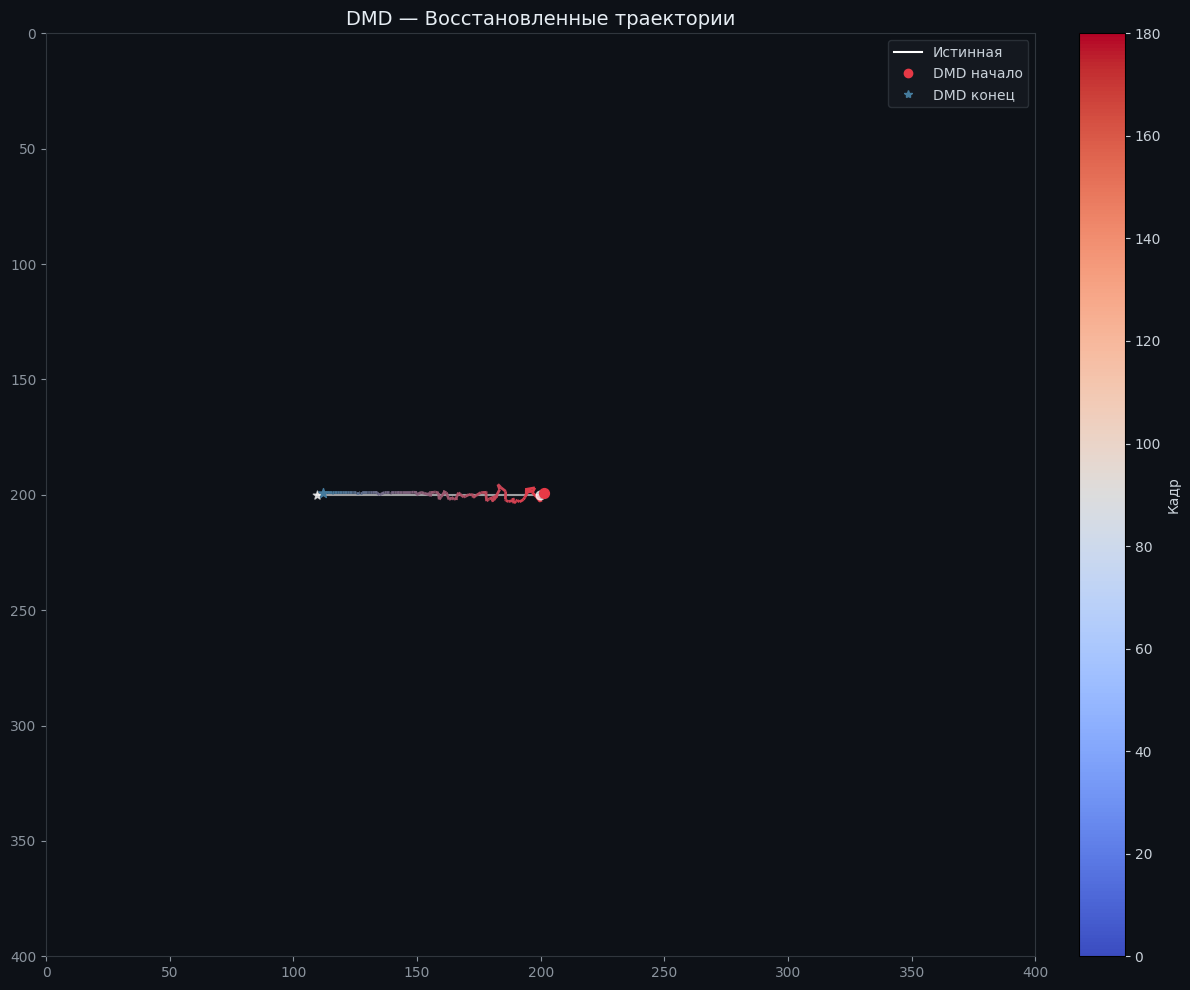

Инициализация | video=1.mp4 | rank=5
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=181 | 
объектов=1
fit_dmd | rank=5 | 
|λ|=[1.0016, 1.0123] | 
14181 ms
track | объектов=1 | кадров=180
track | строим DMD-кадры...
_get_dmd_frames | 276 ms
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           2.367 px
────────────────────────────────────────────────────
 L2 (среднее)                      2.367 px
 Пиковая ошибка                    5.972 px
 Кадр пиковой ошибки                 151
────────────────────────────────────────────────────


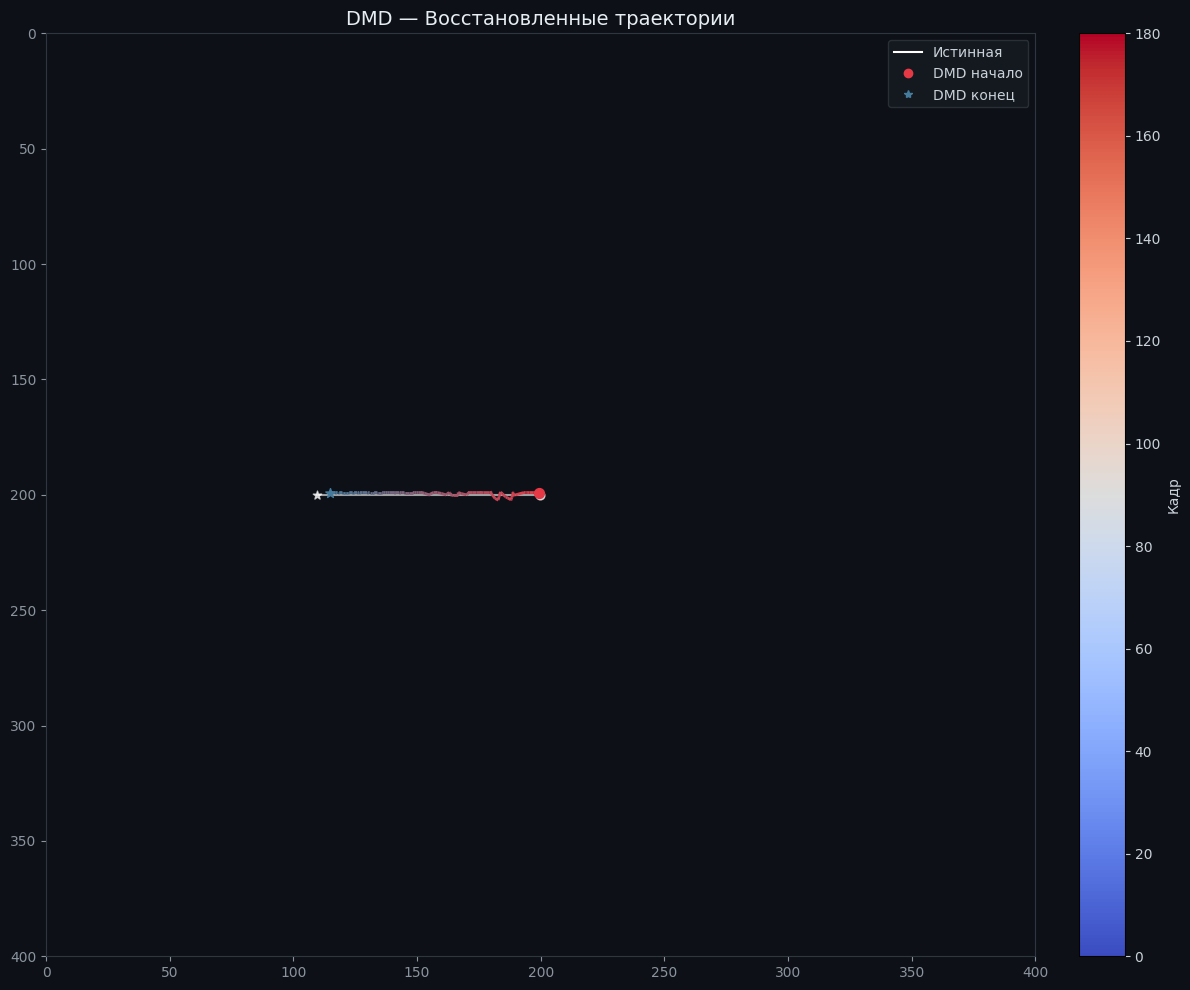

Baseline L2: 2.677 px
DMD L2:      2.367 px


In [11]:
path_mp4 = '1.mp4'
path_csv = '1.csv'

shared = dict(
    source_radius=8.0,
    peak_prominence=0.4,
    proc_noise=5.0,
    meas_noise=10.0,
    adapt_window=0,
    coast_limit=5,
)

tracker_baseline = DMDTracker(path_mp4, path_csv, use_dmd=False, **shared)
results_baseline = tracker_baseline.run()

tracker_dmd = DMDTracker(path_mp4, path_csv,
    use_dmd=True,
    svd_rank=5,
    top_k_modes=5,
    static_tol=0.1,
    **shared,
)
results_dmd = tracker_dmd.run()

print(f"Baseline L2: {results_baseline['metrics'].l2_mean:.3f} px")
print(f"DMD L2:      {results_dmd['metrics'].l2_mean:.3f} px")

## 2

Инициализация | video=2.mp4 | rank=0
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=181 | 
объектов=1
track | объектов=1 | кадров=180
track | DMD отключён, используем сырые кадры...
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                          10.939 px
────────────────────────────────────────────────────
 L2 (среднее)                     10.939 px
 Пиковая ошибка                   43.739 px
 Кадр пиковой ошибки                 161
────────────────────────────────────────────────────


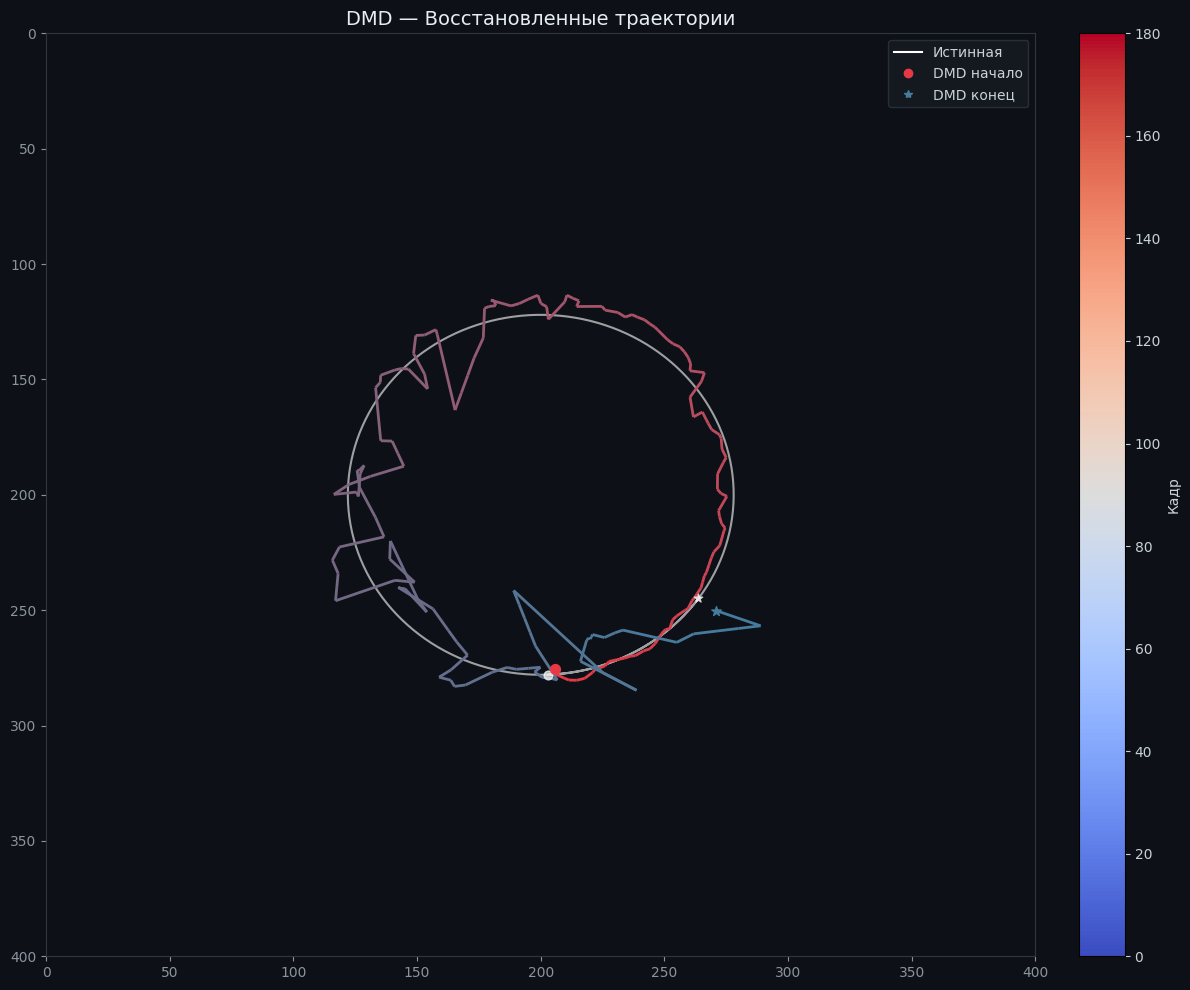

Инициализация | video=2.mp4 | rank=13
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=181 | 
объектов=1
fit_dmd | rank=13 | 
|λ|=[1.0018, 1.0052] | 
15502 ms
track | объектов=1 | кадров=180
track | строим DMD-кадры...
_get_dmd_frames | 333 ms
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           8.811 px
────────────────────────────────────────────────────
 L2 (среднее)                      8.811 px
 Пиковая ошибка                   62.015 px
 Кадр пиковой ошибки                 156
────────────────────────────────────────────────────


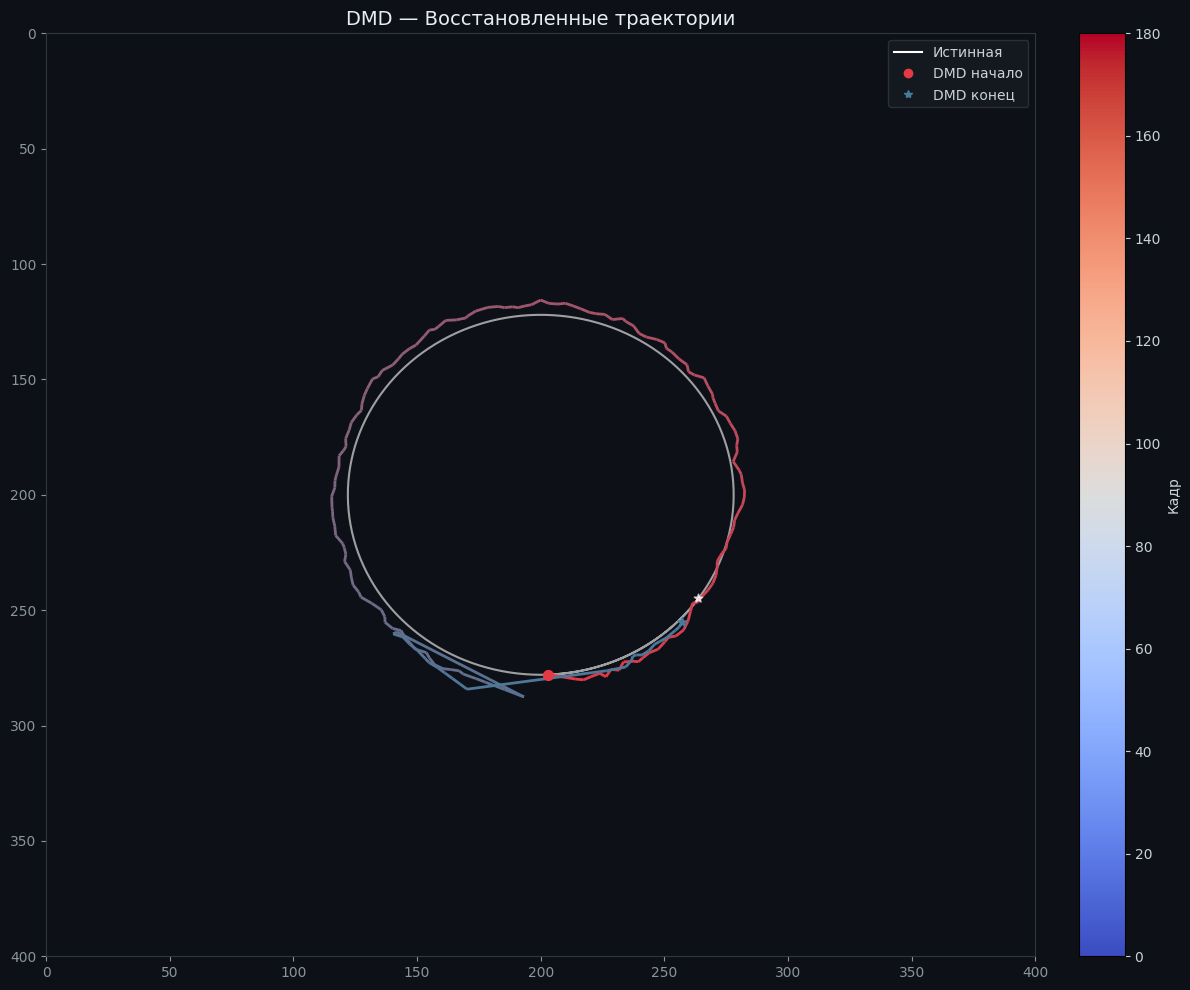

Baseline L2: 10.939 px
DMD L2:      8.811 px


In [12]:
path_mp4 = '2.mp4'
path_csv = '2.csv'

shared = dict(
    source_radius=8.0,
    peak_prominence=0.4,
    proc_noise=5.0,
    meas_noise=10.0,
    adapt_window=0,
    coast_limit=5,
)

tracker_baseline = DMDTracker(path_mp4, path_csv, use_dmd=False, **shared)
results_baseline = tracker_baseline.run()

tracker_dmd = DMDTracker(path_mp4, path_csv,
    use_dmd=True,
    svd_rank=13,
    top_k_modes=10,
    static_tol=0.1,
    **shared,
)
results_dmd = tracker_dmd.run()

print(f"Baseline L2: {results_baseline['metrics'].l2_mean:.3f} px")
print(f"DMD L2:      {results_dmd['metrics'].l2_mean:.3f} px")

## 3

Инициализация | video=3.mp4 | rank=0
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=181 | 
объектов=1
track | объектов=1 | кадров=180
track | DMD отключён, используем сырые кадры...
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           3.760 px
────────────────────────────────────────────────────
 L2 (среднее)                      3.760 px
 Пиковая ошибка                    6.898 px
 Кадр пиковой ошибки                 157
────────────────────────────────────────────────────


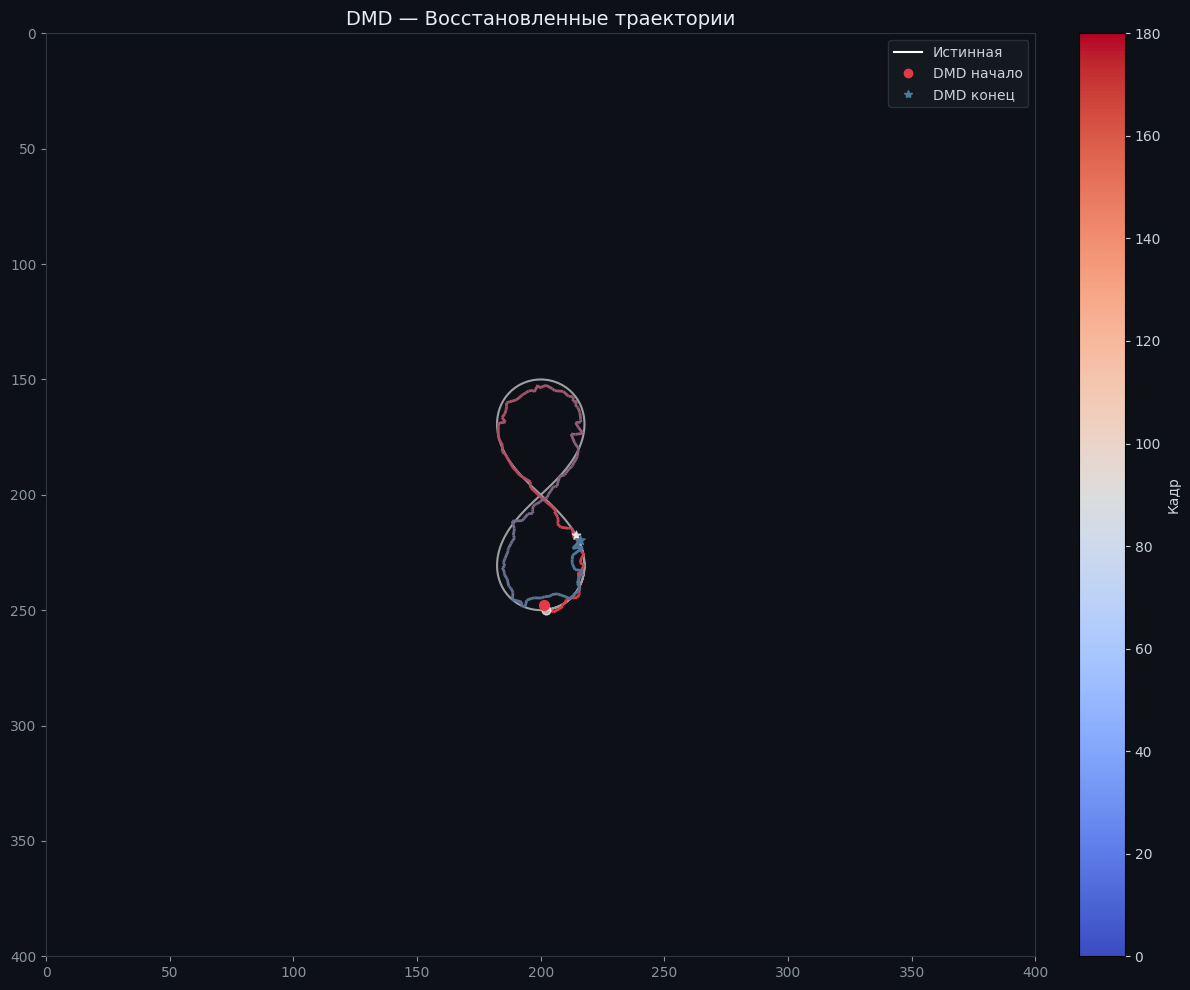

Инициализация | video=3.mp4 | rank=28
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=181 | 
объектов=1
fit_dmd | rank=28 | 
|λ|=[0.9731, 1.0067] | 
14385 ms
track | объектов=1 | кадров=180
track | строим DMD-кадры...
_get_dmd_frames | 311 ms
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           3.446 px
────────────────────────────────────────────────────
 L2 (среднее)                      3.446 px
 Пиковая ошибка                    7.926 px
 Кадр пиковой ошибки                 104
────────────────────────────────────────────────────


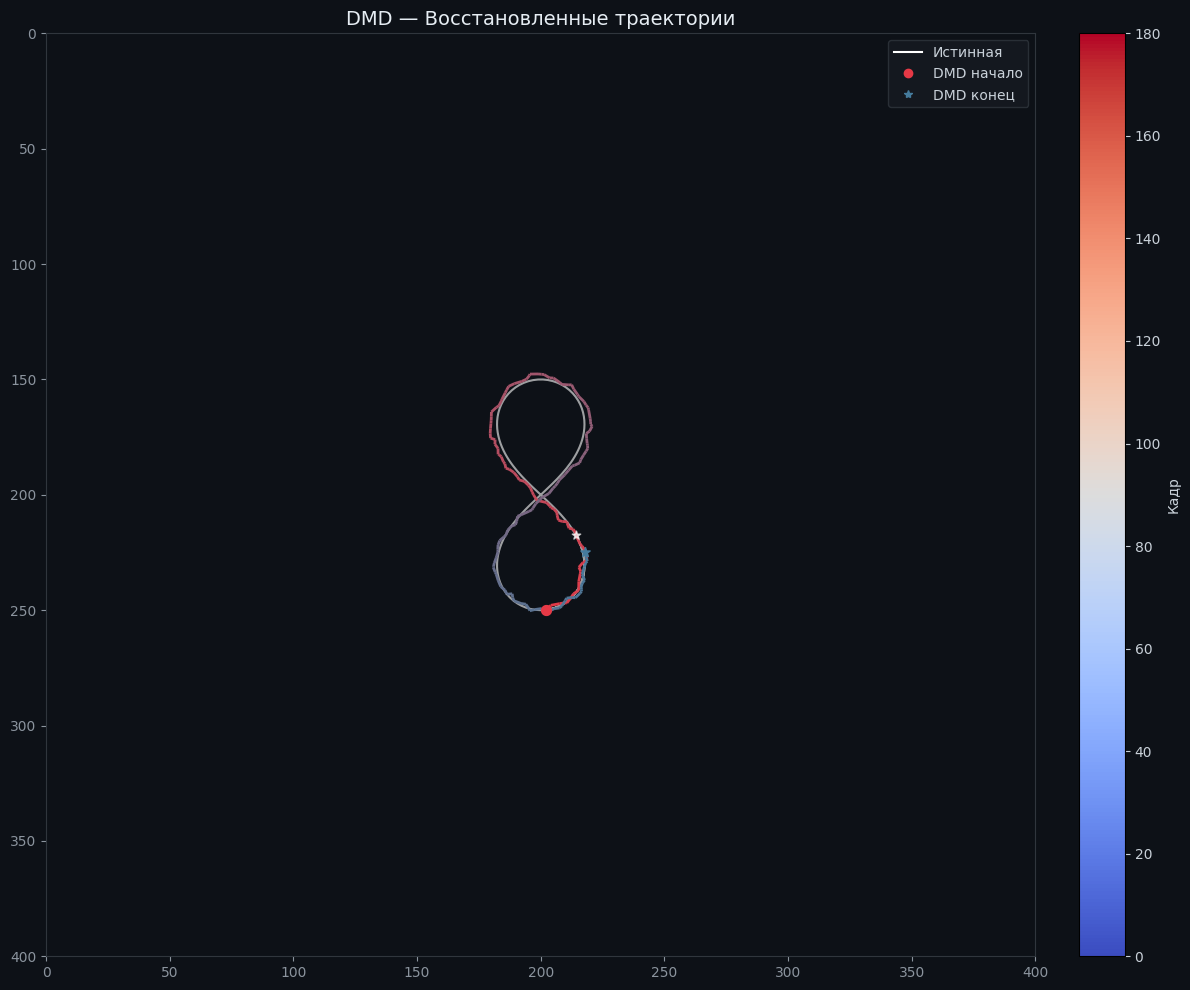

Baseline L2: 3.760 px
DMD L2:      3.446 px


In [14]:
path_mp4 = '3.mp4'
path_csv = '3.csv'

shared = dict(
    source_radius=8.0,
    peak_prominence=0.4,
    proc_noise=5.0,
    meas_noise=10.0,
    adapt_window=0,
    coast_limit=5,
)

tracker_baseline = DMDTracker(path_mp4, path_csv, use_dmd=False, **shared)
results_baseline = tracker_baseline.run()

tracker_dmd = DMDTracker(path_mp4, path_csv,
    use_dmd=True,
    svd_rank=28,
    top_k_modes=12,
    static_tol=0.015,
    **shared,
)
results_dmd = tracker_dmd.run()

print(f"Baseline L2: {results_baseline['metrics'].l2_mean:.3f} px")
print(f"DMD L2:      {results_dmd['metrics'].l2_mean:.3f} px")

## 4

Инициализация | video=4.mp4 | rank=0
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=362 | 
объектов=2
track | объектов=2 | кадров=180
track | DMD отключён, используем сырые кадры...
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           3.761 px
 L2 объект 1                           4.107 px
────────────────────────────────────────────────────
 L2 (среднее)                      3.934 px
 Пиковая ошибка                    9.756 px
 Кадр пиковой ошибки                 137
────────────────────────────────────────────────────


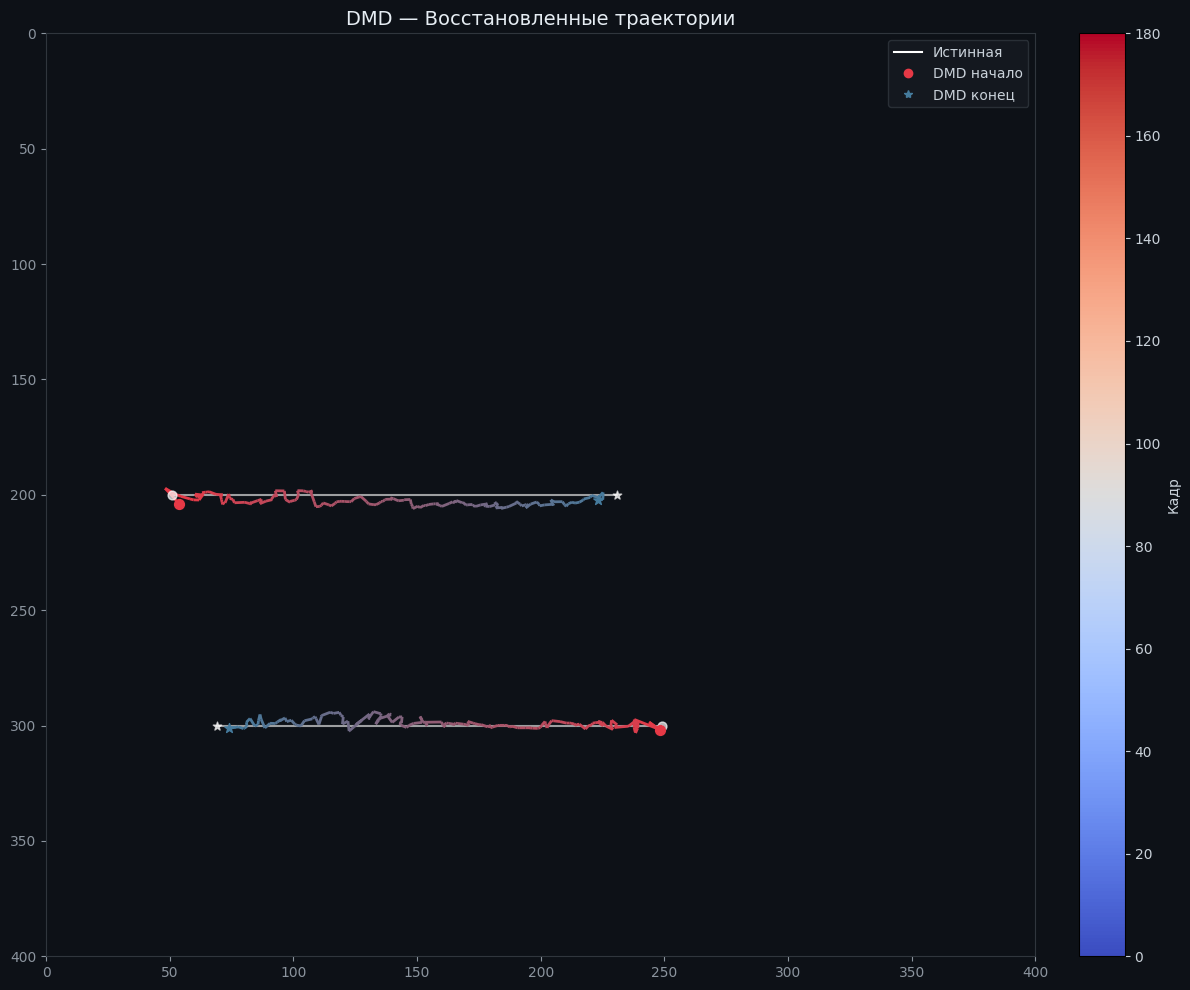

Инициализация | video=4.mp4 | rank=10
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=362 | 
объектов=2
fit_dmd | rank=10 | 
|λ|=[0.9970, 1.0155] | 
14433 ms
track | объектов=2 | кадров=180
track | строим DMD-кадры...
_get_dmd_frames | 286 ms
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           2.848 px
 L2 объект 1                           2.161 px
────────────────────────────────────────────────────
 L2 (среднее)                      2.505 px
 Пиковая ошибка                    6.609 px
 Кадр пиковой ошибки                 137
────────────────────────────────────────────────────


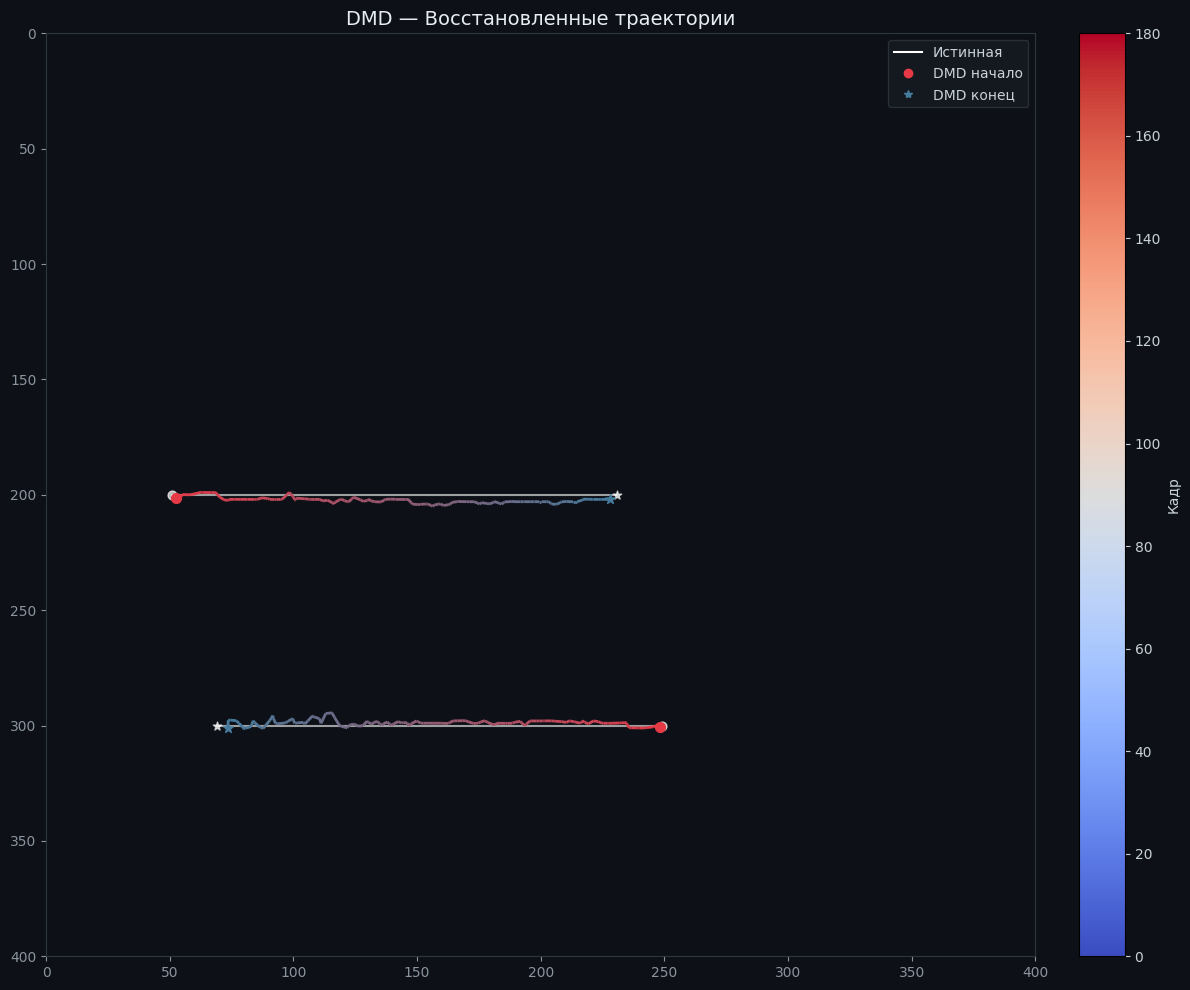

Baseline L2: 3.934 px
DMD L2:      2.505 px


In [15]:
path_mp4 = '4.mp4'
path_csv = '4.csv'

shared = dict(
    source_radius=8.0,
    peak_prominence=0.4,
    proc_noise=5.0,
    meas_noise=10.0,
    adapt_window=0,
    coast_limit=5,
)

tracker_baseline = DMDTracker(path_mp4, path_csv, use_dmd=False, **shared)
results_baseline = tracker_baseline.run()

tracker_dmd = DMDTracker(path_mp4, path_csv,
    use_dmd=True,
    svd_rank=10,
    top_k_modes=10,
    static_tol=0.02,
    **shared,
)
results_dmd = tracker_dmd.run()

print(f"Baseline L2: {results_baseline['metrics'].l2_mean:.3f} px")
print(f"DMD L2:      {results_dmd['metrics'].l2_mean:.3f} px")

## 5

Инициализация | video=5.mp4 | rank=0
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=362 | 
объектов=2
track | объектов=2 | кадров=180
track | DMD отключён, используем сырые кадры...
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                         116.316 px
 L2 объект 1                          16.934 px
────────────────────────────────────────────────────
 L2 (среднее)                     66.625 px
 Пиковая ошибка                  194.423 px
 Кадр пиковой ошибки                 175
────────────────────────────────────────────────────


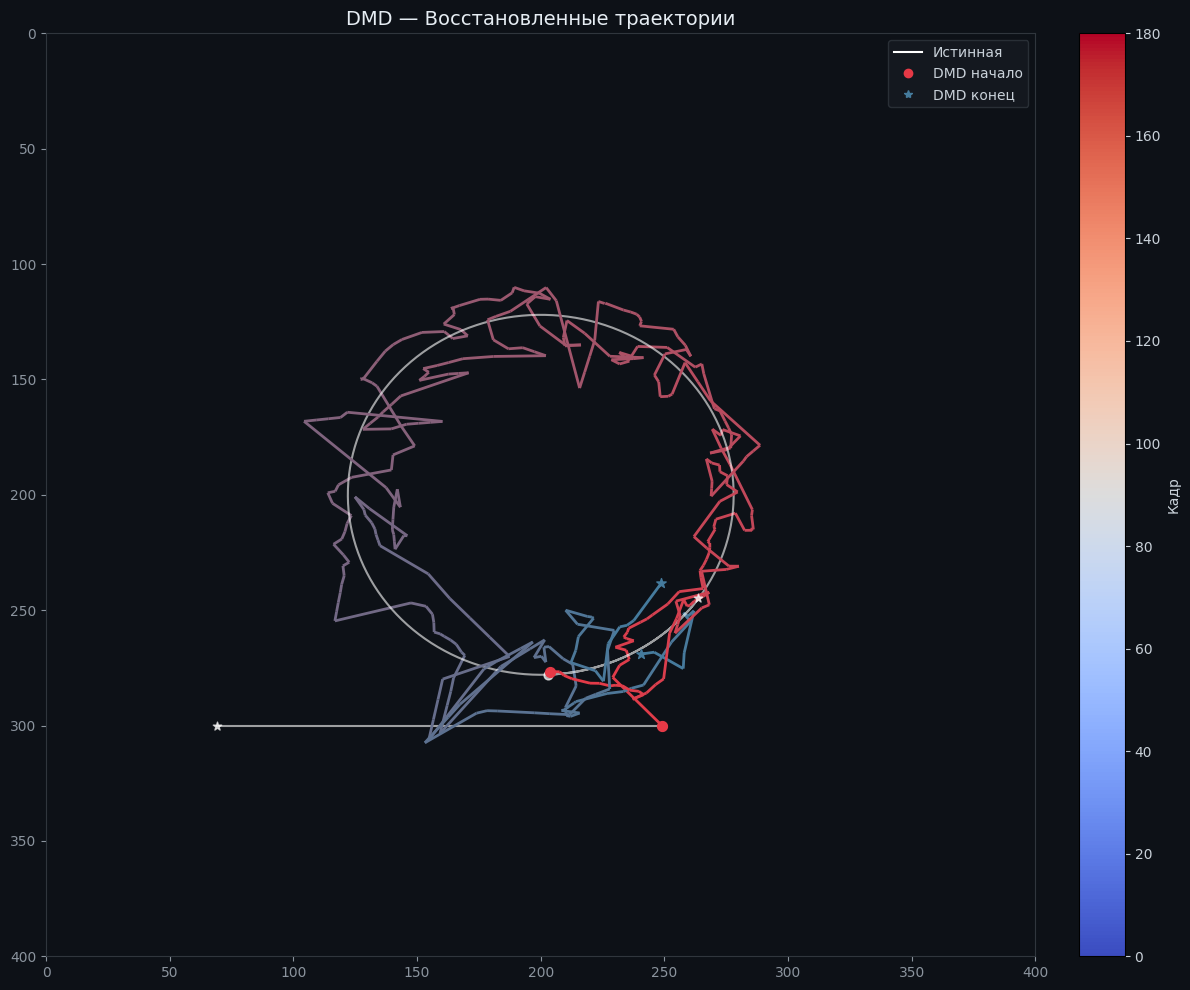

Инициализация | video=5.mp4 | rank=54
load_video | кадров=180 | 
размер=(400, 400) | матрица=(160000, 180)
load_ground_truth | точек=362 | 
объектов=2
fit_dmd | rank=54 | 
|λ|=[0.6838, 1.0069] | 
15352 ms
track | объектов=2 | кадров=180
track | строим DMD-кадры...
_get_dmd_frames | 315 ms
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                          39.401 px
 L2 объект 1                          27.247 px
────────────────────────────────────────────────────
 L2 (среднее)                     33.324 px
 Пиковая ошибка                  169.448 px
 Кадр пиковой ошибки                 151
────────────────────────────────────────────────────


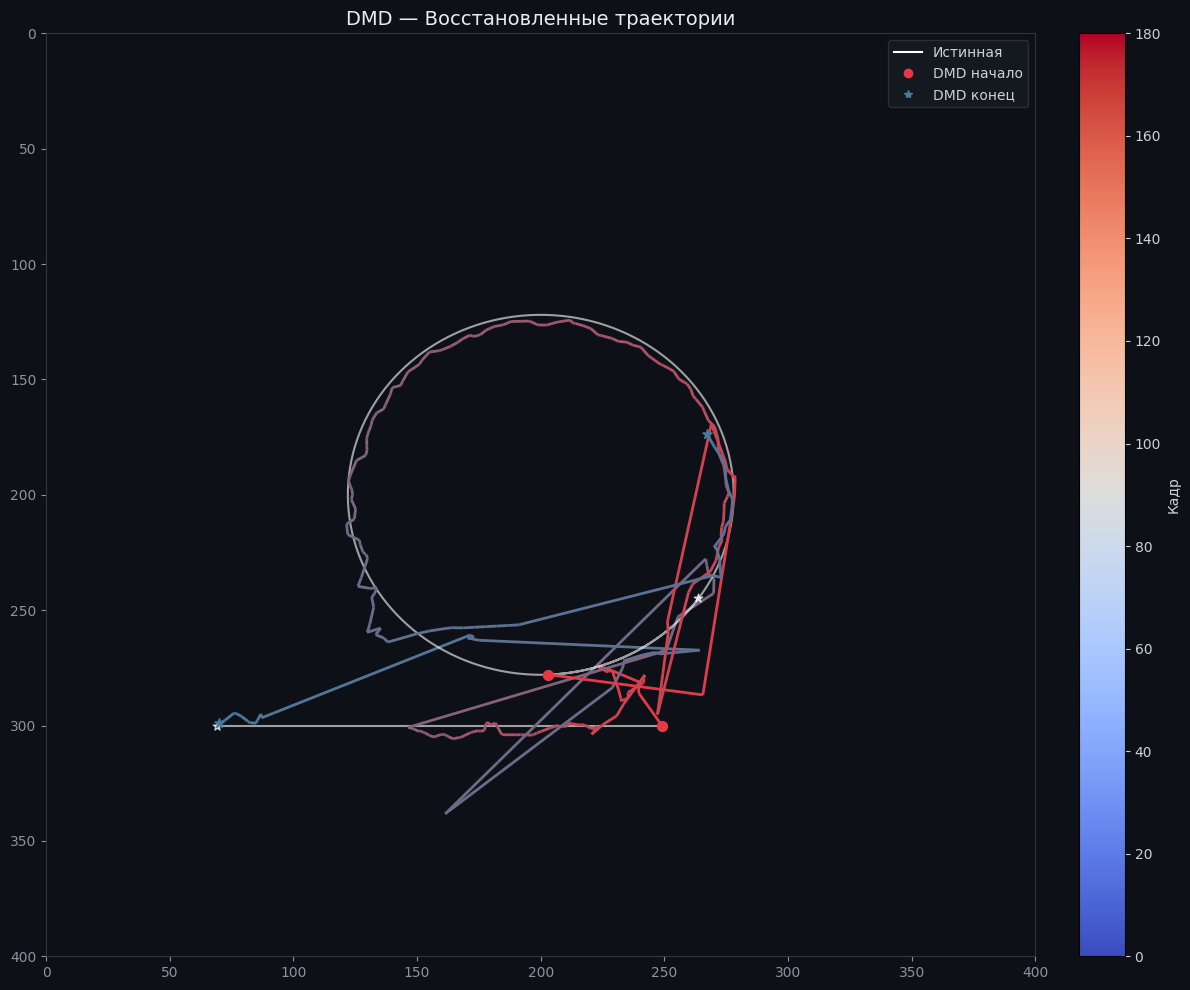

Baseline L2: 66.625 px
DMD L2:      33.324 px


In [16]:
path_mp4 = '5.mp4'
path_csv = '5.csv'

shared = dict(
    source_radius=8.0,
    peak_prominence=0.4,
    proc_noise=5.0,
    meas_noise=10.0,
    adapt_window=0,
    coast_limit=5,
)

tracker_baseline = DMDTracker(path_mp4, path_csv, use_dmd=False, **shared)
results_baseline = tracker_baseline.run()

tracker_dmd = DMDTracker(path_mp4, path_csv,
    use_dmd=True,
    svd_rank=54,
    top_k_modes=12,
    static_tol=0.008,
    **shared,
)
results_dmd = tracker_dmd.run()

print(f"Baseline L2: {results_baseline['metrics'].l2_mean:.3f} px")
print(f"DMD L2:      {results_dmd['metrics'].l2_mean:.3f} px")

Инициализация | video=6.mp4 | rank=0
load_video | кадров=180 | 
размер=(800, 800) | матрица=(640000, 180)
load_ground_truth | точек=543 | 
объектов=3
track | объектов=3 | кадров=180
track | DMD отключён, используем сырые кадры...
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                         206.797 px
 L2 объект 1                         124.004 px
 L2 объект 2                         103.186 px
────────────────────────────────────────────────────
 L2 (среднее)                    144.662 px
 Пиковая ошибка                  478.412 px
 Кадр пиковой ошибки                 135
────────────────────────────────────────────────────


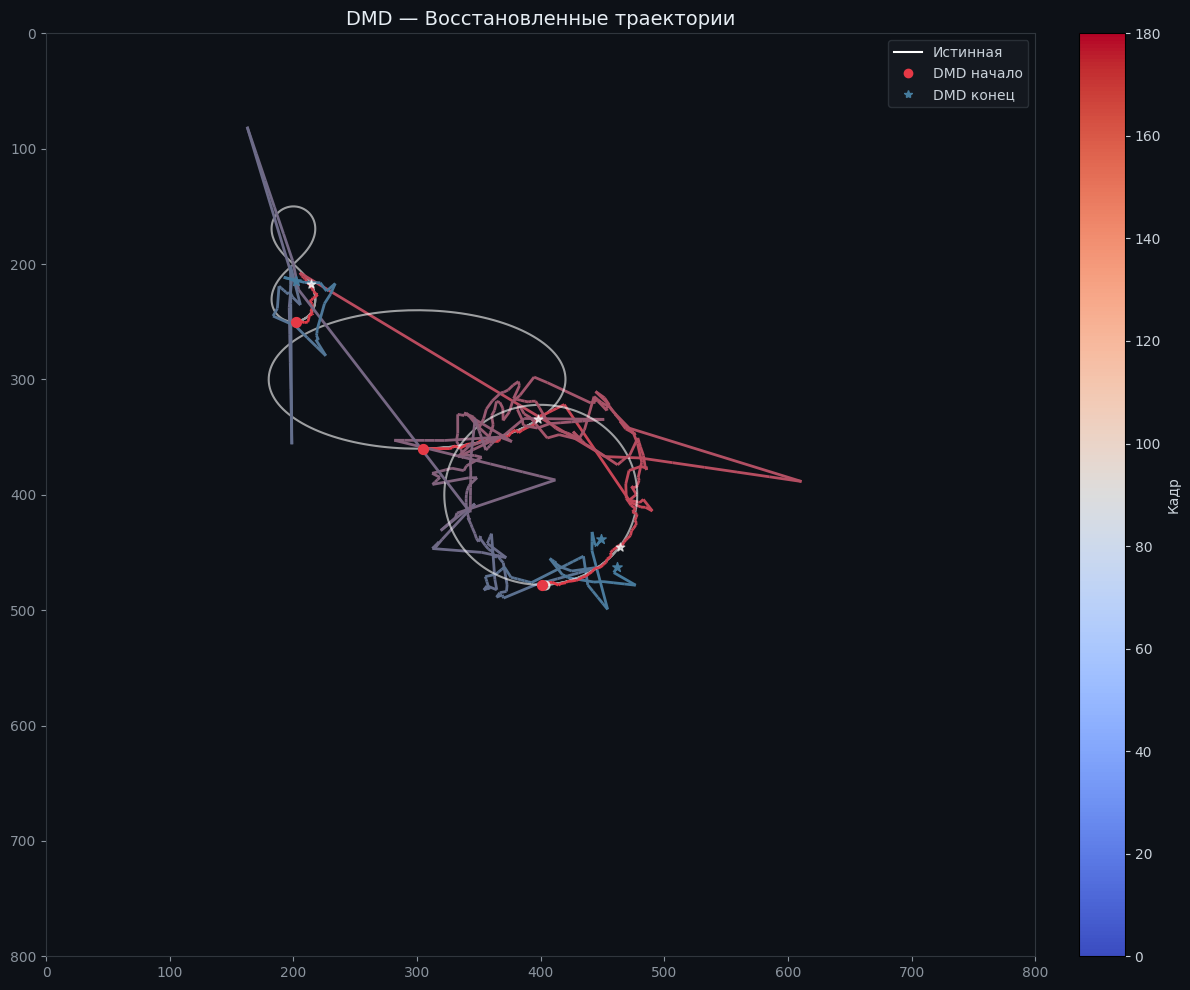

Инициализация | video=6.mp4 | rank=60
load_video | кадров=180 | 
размер=(800, 800) | матрица=(640000, 180)
load_ground_truth | точек=543 | 
объектов=3
fit_dmd | rank=60 | 
|λ|=[0.9371, 1.0037] | 
67832 ms
track | объектов=3 | кадров=180
track | строим DMD-кадры...
_get_dmd_frames | 2373 ms
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           4.387 px
 L2 объект 1                           9.775 px
 L2 объект 2                          10.370 px
────────────────────────────────────────────────────
 L2 (среднее)                      8.178 px
 Пиковая ошибка                   45.321 px
 Кадр пиковой ошибки                  19
────────────────────────────────────────────────────


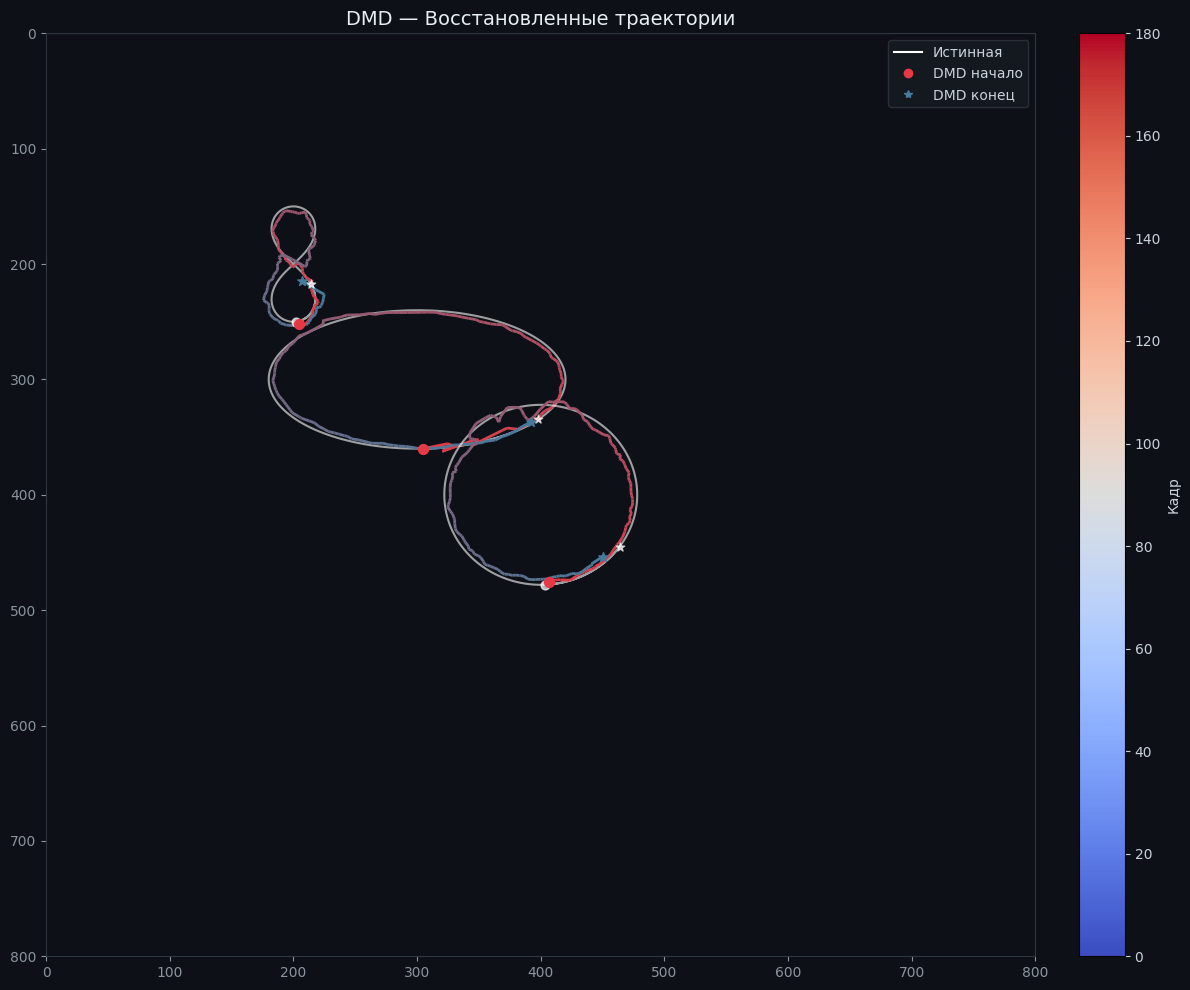

Baseline L2: 144.662 px
DMD L2:      8.178 px


In [17]:
path_mp4 = '6.mp4'
path_csv = '6.csv'

shared = dict(
    source_radius=8.0,
    peak_prominence=0.4,
    proc_noise=5.0,
    meas_noise=10.0,
    adapt_window=0,
    coast_limit=5,
)

tracker_baseline = DMDTracker(path_mp4, path_csv, use_dmd=False, **shared)
results_baseline = tracker_baseline.run()

tracker_dmd = DMDTracker(path_mp4, path_csv,
    use_dmd=True,
    svd_rank=60,
    top_k_modes=20,
    static_tol=0.01,
    **shared,
)
results_dmd = tracker_dmd.run()

print(f"Baseline L2: {results_baseline['metrics'].l2_mean:.3f} px")
print(f"DMD L2:      {results_dmd['metrics'].l2_mean:.3f} px")

## 7

Инициализация | video=7.mp4 | rank=0
load_video | кадров=180 | 
размер=(800, 800) | матрица=(640000, 180)
load_ground_truth | точек=362 | 
объектов=2
track | объектов=2 | кадров=180
track | DMD отключён, используем сырые кадры...
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           5.657 px
 L2 объект 1                           5.708 px
────────────────────────────────────────────────────
 L2 (среднее)                      5.682 px
 Пиковая ошибка                   13.075 px
 Кадр пиковой ошибки                 115
────────────────────────────────────────────────────


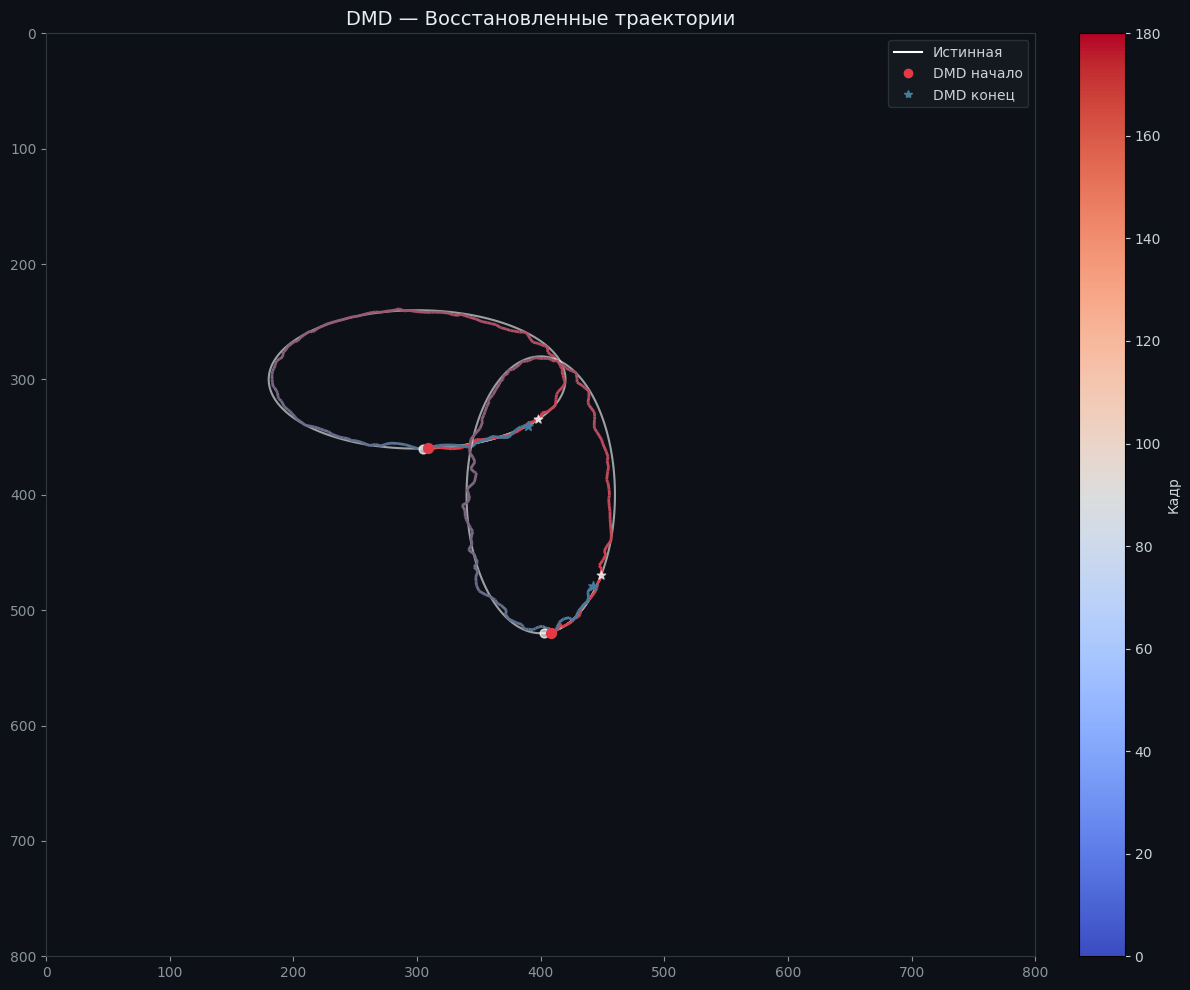

Инициализация | video=7.mp4 | rank=70
load_video | кадров=180 | 
размер=(800, 800) | матрица=(640000, 180)
load_ground_truth | точек=362 | 
объектов=2
fit_dmd | rank=70 | 
|λ|=[0.4688, 1.0006] | 
66776 ms
track | объектов=2 | кадров=180
track | строим DMD-кадры...
_get_dmd_frames | 1911 ms
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           6.165 px
 L2 объект 1                           4.136 px
────────────────────────────────────────────────────
 L2 (среднее)                      5.150 px
 Пиковая ошибка                   13.457 px
 Кадр пиковой ошибки                   8
────────────────────────────────────────────────────


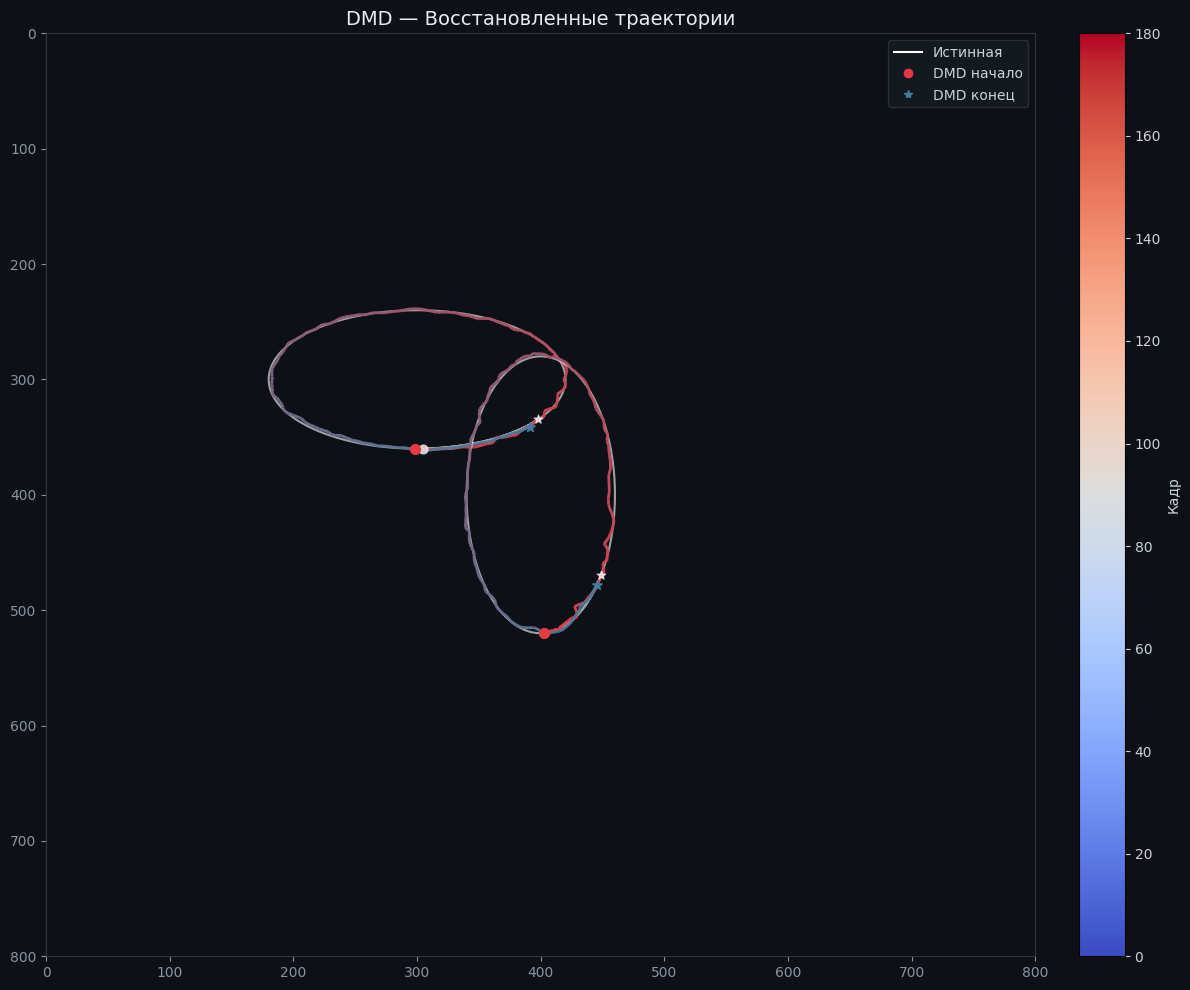

Baseline L2: 5.682 px
DMD L2:      5.150 px


In [18]:
path_mp4 = '7.mp4'
path_csv = '7.csv'

shared = dict(
    source_radius=8.0,
    peak_prominence=0.4,
    proc_noise=5.0,
    meas_noise=10.0,
    adapt_window=0,
    coast_limit=5,
)

tracker_baseline = DMDTracker(path_mp4, path_csv, use_dmd=False, **shared)
results_baseline = tracker_baseline.run()

tracker_dmd = DMDTracker(path_mp4, path_csv,
    use_dmd=True,
    svd_rank=70,
    top_k_modes=30,
    static_tol=0.02,
    **shared,
)
results_dmd = tracker_dmd.run()

print(f"Baseline L2: {results_baseline['metrics'].l2_mean:.3f} px")
print(f"DMD L2:      {results_dmd['metrics'].l2_mean:.3f} px")

## 8

Инициализация | video=8.mp4 | rank=0
load_video | кадров=180 | 
размер=(800, 800) | матрица=(640000, 180)
load_ground_truth | точек=543 | 
объектов=3
track | объектов=3 | кадров=180
track | DMD отключён, используем сырые кадры...
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                         152.950 px
 L2 объект 1                         100.538 px
 L2 объект 2                          13.794 px
────────────────────────────────────────────────────
 L2 (среднее)                     89.094 px
 Пиковая ошибка                  313.596 px
 Кадр пиковой ошибки                  78
────────────────────────────────────────────────────


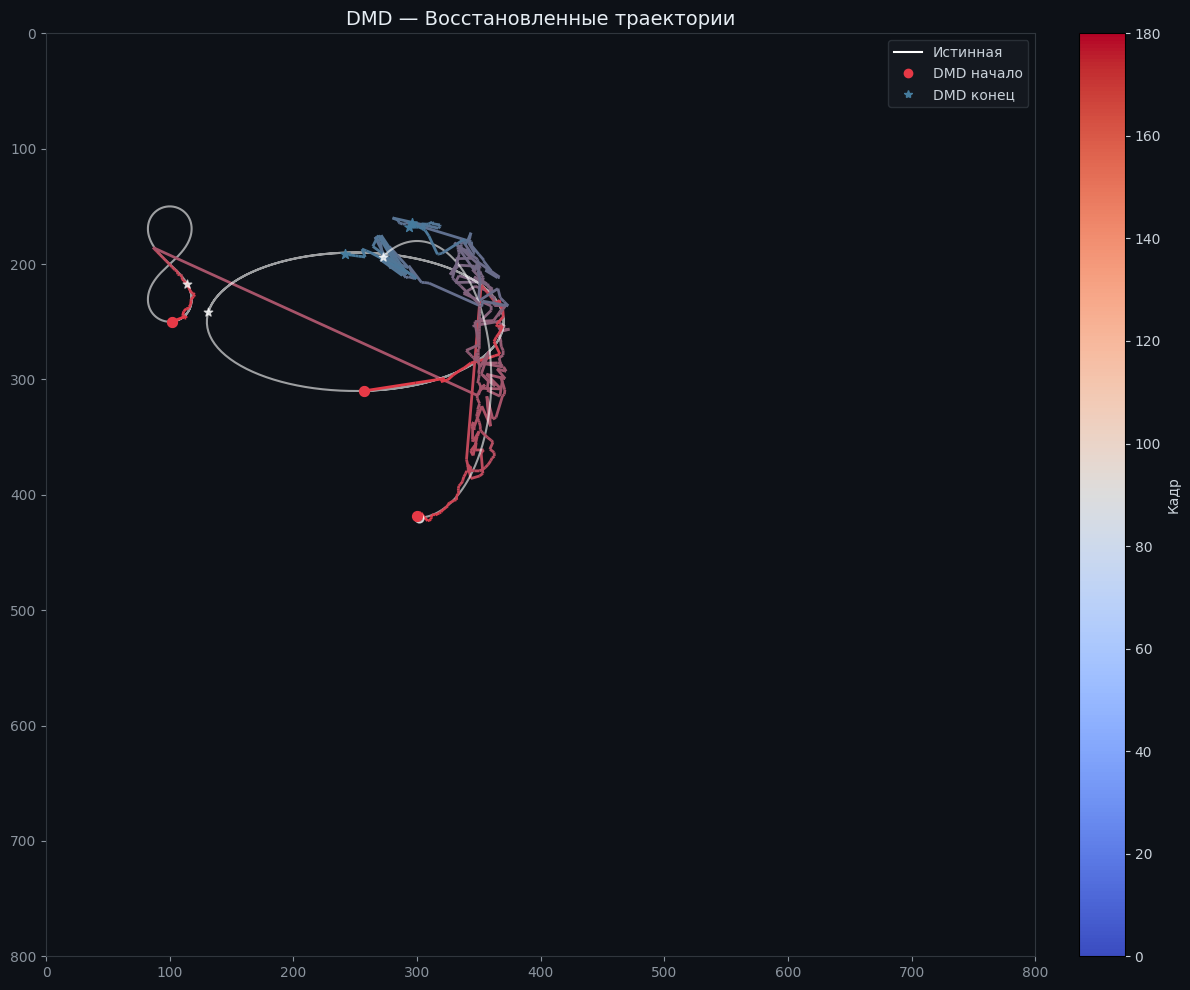

Инициализация | video=8.mp4 | rank=61
load_video | кадров=180 | 
размер=(800, 800) | матрица=(640000, 180)
load_ground_truth | точек=543 | 
объектов=3
fit_dmd | rank=61 | 
|λ|=[0.1628, 1.0101] | 
73860 ms
track | объектов=3 | кадров=180
track | строим DMD-кадры...
_get_dmd_frames | 1921 ms
track | готово | кадров=180
────────────────────────────────────────────────────
 Метрика                        Значение
────────────────────────────────────────────────────
 L2 объект 0                           8.524 px
 L2 объект 1                          57.300 px
 L2 объект 2                          11.769 px
────────────────────────────────────────────────────
 L2 (среднее)                     25.864 px
 Пиковая ошибка                  223.963 px
 Кадр пиковой ошибки                 162
────────────────────────────────────────────────────


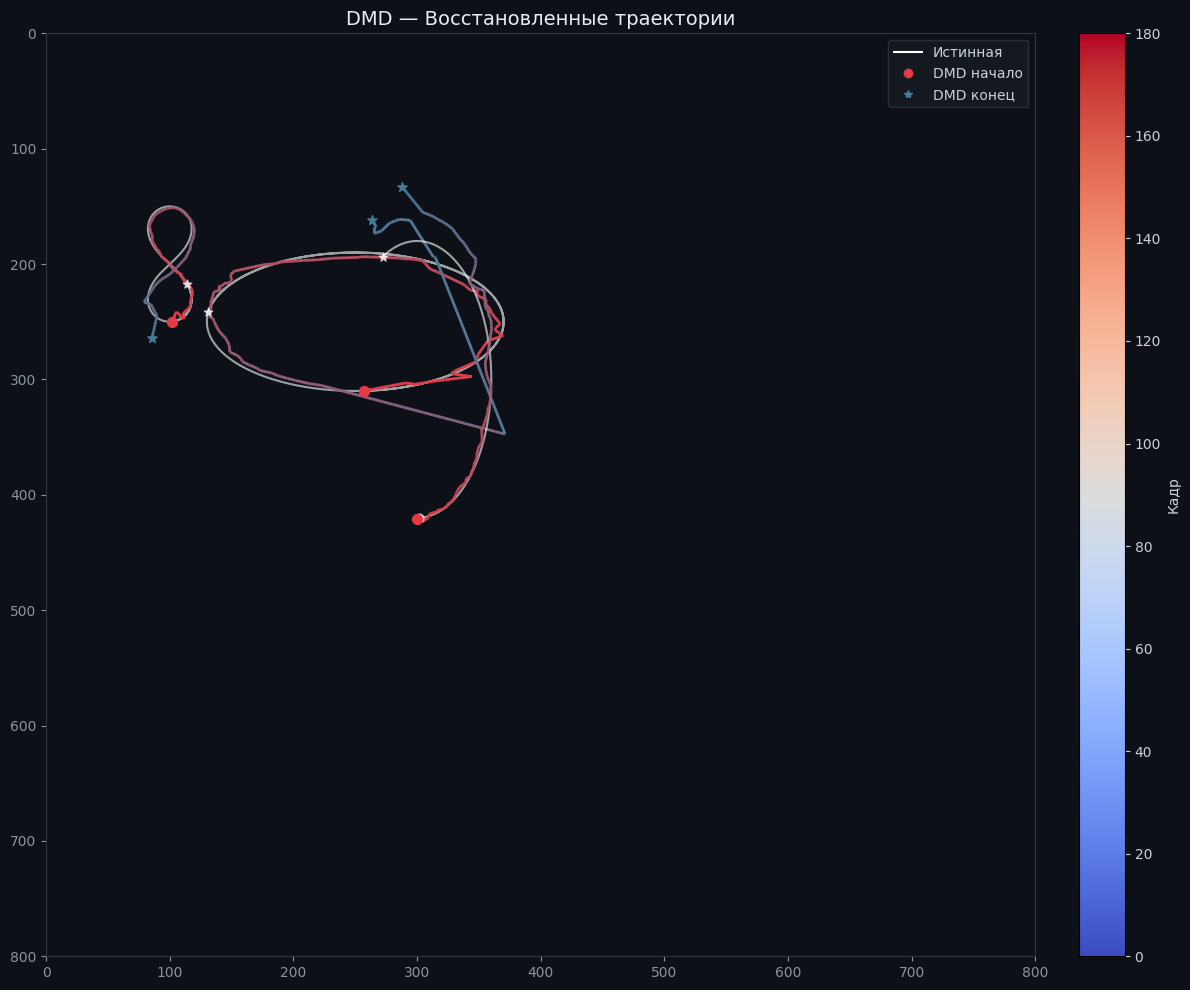

Baseline L2: 89.094 px
DMD L2:      25.864 px


In [20]:
path_mp4 = '8.mp4'
path_csv = '8.csv'

shared = dict(
    source_radius=6.0,
    peak_prominence=0.4,
    proc_noise=8.0,
    meas_noise=10.0,
    adapt_window=20,
    coast_limit=15,
)

tracker_baseline = DMDTracker(path_mp4, path_csv, use_dmd=False, **shared)
results_baseline = tracker_baseline.run()

tracker_dmd = DMDTracker(path_mp4, path_csv,
    use_dmd=True,
    svd_rank=61,
    top_k_modes=20,
    static_tol=0.01,
    **shared,
)
results_dmd = tracker_dmd.run()

print(f"Baseline L2: {results_baseline['metrics'].l2_mean:.3f} px")
print(f"DMD L2:      {results_dmd['metrics'].l2_mean:.3f} px")